In [8]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [9]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = "750-50"
obs_mode = "IPOL"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
# print("Interleaved Values")
# print("Length: ", len(interleaved_values))
# print(interleaved_values)
# print("Interleaved Stds")
# print("Length: ", len(interleaved_stds))
# print(interleaved_stds[0 : 10])
# print("Configuration List")
# print("Length: ", len(configuration_list))
# print(configuration_list)
# print(interleaved_stds[0])

# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [10]:
# This copied legacy cell used to load a 720 nm .npy start vector.
# The 750 nm fixed-EM IMR-offset fit starts from the JSON file in the next cell.

In [11]:
# Loading in previous fit from vampires_calibration
filename = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/750-50_restrictive_HWP_FLC_no_IMR_offset_fixed_EM_gain_with_dichroic_best_fit.txt"
with open(filename, "r") as f:
    past_fit = json.load(f)

print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
# Start from zero when the previous no-offset fit has no IMR offset saved.
offset_derot = np.clip(past_fit.get("image_rotator", {}).get("delta_theta", 0), -1, 1)
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
em_gain = 1.189163823178048  # calculated in em_gain_calculations/20230919_calculate_em_gain_ratios.ipynb

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.64  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {'phi': 0, 'epsilon': 0, 'theta': 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {'phi': delta_opts, 'epsilon': epsilon_opts, 'theta': rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

print(system_dict)

{'dichroic': {'phi': -0.15060529133346875, 'epsilon': 0.2947260746883915, 'theta': 35.808129724830195}, 'flc': {'phi': 3.5231674749347714, 'delta_theta': 2.547063907771257}, 'optics': {'phi': 0.8366868576245823, 'epsilon': 3.887450379959534e-09, 'theta': -59.919309379978884}, 'image_rotator': {'phi': 3.0680237129197785}, 'hwp': {'phi': 2.9838983981947838, 'delta_theta': 0.5155838549975353}, 'lp': {'theta': 0.674229408746958}}
{'components': {'wollaston': {'type': 'wollaston_prism_function', 'properties': {'beam': 'o', 'transmission_ratio': 1.189163823178048}}, 'dichroic': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'flc': {'type': 'general_retarder_function', 'properties': {'phi': 3.5231674749347714, 'theta': 0, 'delta_theta': 2.547063907771257}}, 'optics': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0.8366868576245823, 'epsilon': 3.887450379959534e-09, 'theta': -59.919309379978884}}, 'image_rotator': {'type': 'ge

In [12]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.51706085 0.51691766 0.01216793 0.        ]
 [0.51706085 0.51691766 0.01216793 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

logl value: 731.702233881236


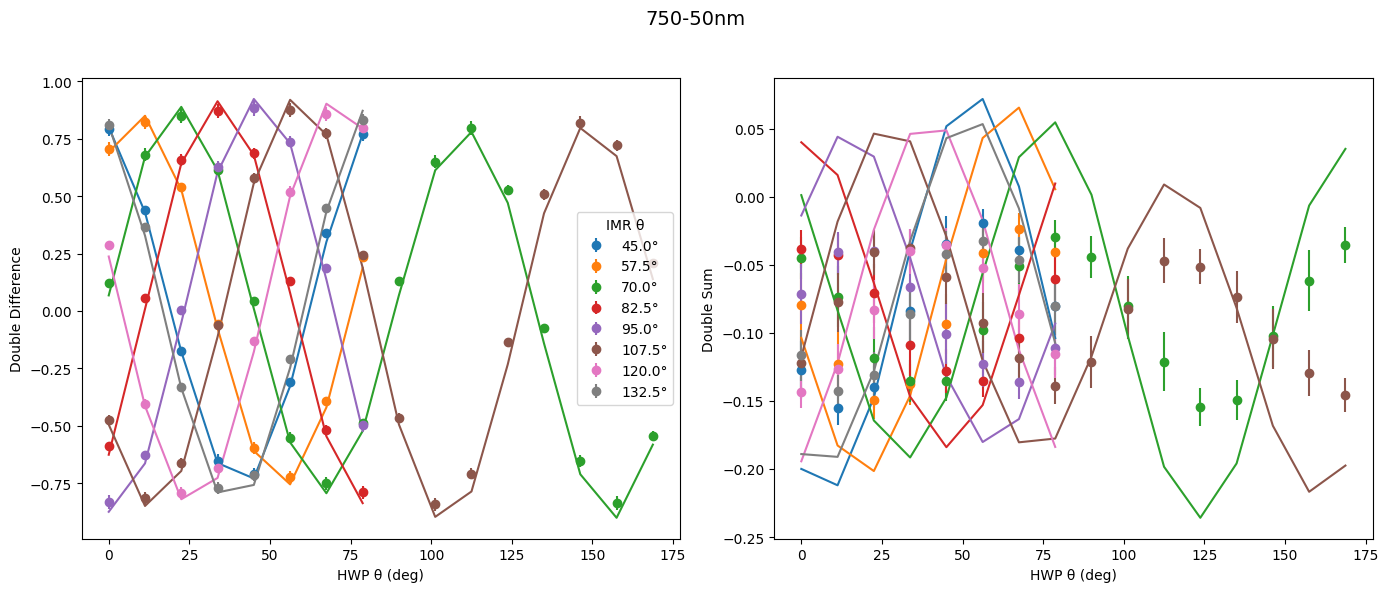

In [13]:
# Fittin for all parameters
p0 = {
    "dichroic": {"phi": 0, 
                 "epsilon": 0, 
                 "theta": 0},
    "flc": {"phi": delta_FLC, "delta_theta": rot_FLC},
    "optics": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
    "image_rotator": {
                    "phi": delta_derot
                    },
    "hwp": {"phi": delta_HWP, "delta_theta": offset_HWP},
    "lp": {"theta": theta_pol}
}

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.5231674749347714, 'delta_theta': 2.547063907771257}, 'optics': {'phi': 0.8366868576245823, 'epsilon': 3.887450379959534e-09, 'theta': -59.919309379978884}, 'image_rotator': {'phi': 3.0680237129197785}, 'hwp': {'phi': 2.9838983981947838, 'delta_theta': 0.5155838549975353}, 'lp': {'theta': 0.674229408746958}}
Iteration #: 1
logl_value: 187.72079790523426
Best Fit Parameters: [-1.34493907e-02  2.99210772e-03  6.98793848e-02  3.26902004e+00
  1.70456693e+00  1.05182090e+00  8.04187992e-08 -6.75666756e+01
  3.07248039e+00  2.98886815e+00 -3.51765396e+00 -4.89771144e+00]


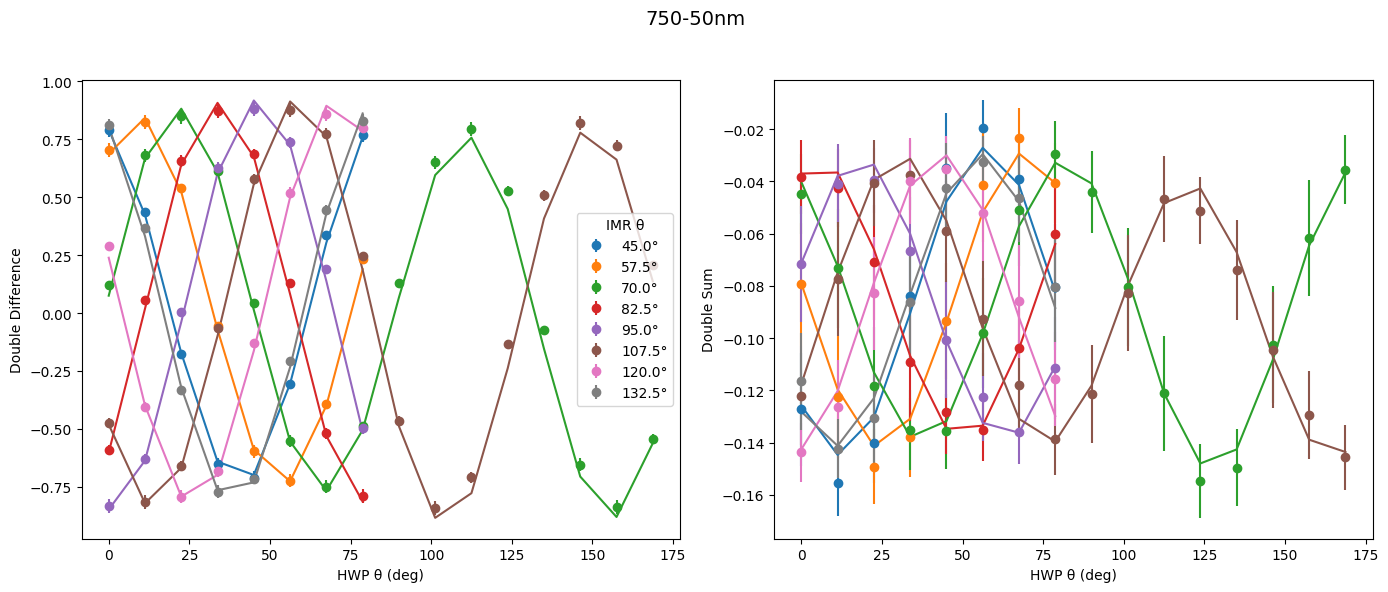

After p0: {'dichroic': {'phi': -0.013449390696560124, 'epsilon': 0.0029921077228352907, 'theta': 0.0698793847635118}, 'flc': {'phi': 3.2690200374593505, 'delta_theta': 1.7045669302448436}, 'optics': {'phi': 1.0518209028627359, 'epsilon': 8.041879918952602e-08, 'theta': -67.56667556202916}, 'image_rotator': {'phi': 3.072480387602484}, 'hwp': {'phi': 2.9888681540095146, 'delta_theta': -3.51765396189216}, 'lp': {'theta': -4.897711437457172}}
Before p0: {'dichroic': {'phi': -0.013449390696560124, 'epsilon': 0.0029921077228352907, 'theta': 0.0698793847635118}, 'flc': {'phi': 3.2690200374593505, 'delta_theta': 1.7045669302448436}, 'optics': {'phi': 1.0518209028627359, 'epsilon': 8.041879918952602e-08, 'theta': -67.56667556202916}, 'image_rotator': {'phi': 3.072480387602484}, 'hwp': {'phi': 2.9888681540095146, 'delta_theta': -3.51765396189216}, 'lp': {'theta': -4.897711437457172}}
Iteration #: 2
logl_value: 187.171748700046
Best Fit Parameters: [ 6.75407703e-04  3.64572024e-03  1.82646609e+00

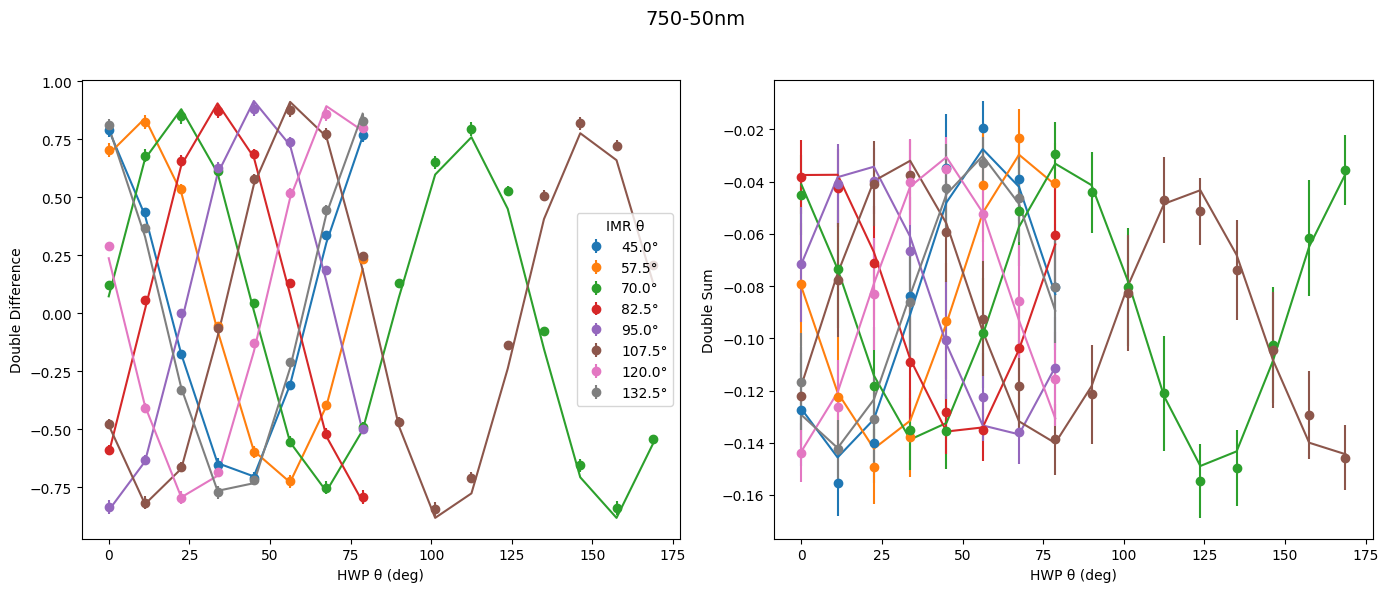

After p0: {'dichroic': {'phi': 0.0006754077031814829, 'epsilon': 0.003645720238397975, 'theta': 1.8264660866219167}, 'flc': {'phi': 3.2676996488275174, 'delta_theta': 2.27137910870493}, 'optics': {'phi': 1.0435916685296647, 'epsilon': 0.00016789876428882736, 'theta': -66.33912622306792}, 'image_rotator': {'phi': 3.074432516096153}, 'hwp': {'phi': 2.991031976463999, 'delta_theta': -3.979610272149282}, 'lp': {'theta': -4.692544901311534}}
Before p0: {'dichroic': {'phi': 0.0006754077031814829, 'epsilon': 0.003645720238397975, 'theta': 1.8264660866219167}, 'flc': {'phi': 3.2676996488275174, 'delta_theta': 2.27137910870493}, 'optics': {'phi': 1.0435916685296647, 'epsilon': 0.00016789876428882736, 'theta': -66.33912622306792}, 'image_rotator': {'phi': 3.074432516096153}, 'hwp': {'phi': 2.991031976463999, 'delta_theta': -3.979610272149282}, 'lp': {'theta': -4.692544901311534}}
Iteration #: 3
logl_value: 116.96136113696983
Best Fit Parameters: [-1.93547394e-01  4.63060047e-03  4.97668404e+00  

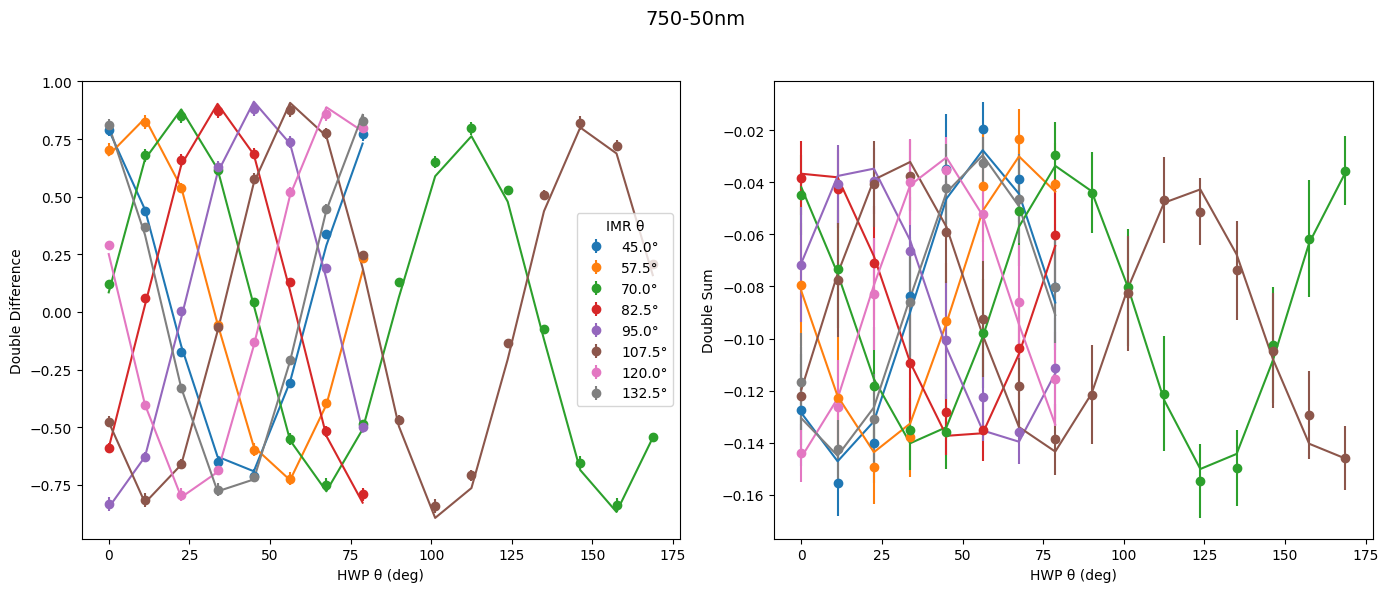

After p0: {'dichroic': {'phi': -0.19354739375130725, 'epsilon': 0.004630600474802597, 'theta': 4.9766840358427284}, 'flc': {'phi': 3.3725127114182047, 'delta_theta': -3.097890055918997}, 'optics': {'phi': 1.0216109704907468, 'epsilon': 0.02212793095588391, 'theta': -74.28776744093702}, 'image_rotator': {'phi': 3.0650795580465005}, 'hwp': {'phi': 3.008891493882505, 'delta_theta': 4.913060188665138}, 'lp': {'theta': 0.8013217087495487}}
Before p0: {'dichroic': {'phi': -0.19354739375130725, 'epsilon': 0.004630600474802597, 'theta': 4.9766840358427284}, 'flc': {'phi': 3.3725127114182047, 'delta_theta': -3.097890055918997}, 'optics': {'phi': 1.0216109704907468, 'epsilon': 0.02212793095588391, 'theta': -74.28776744093702}, 'image_rotator': {'phi': 3.0650795580465005}, 'hwp': {'phi': 3.008891493882505, 'delta_theta': 4.913060188665138}, 'lp': {'theta': 0.8013217087495487}}
Iteration #: 4
logl_value: 26.42719281470202
Best Fit Parameters: [ 1.28651541e-02  2.66431527e-03  3.96217743e+00  3.264

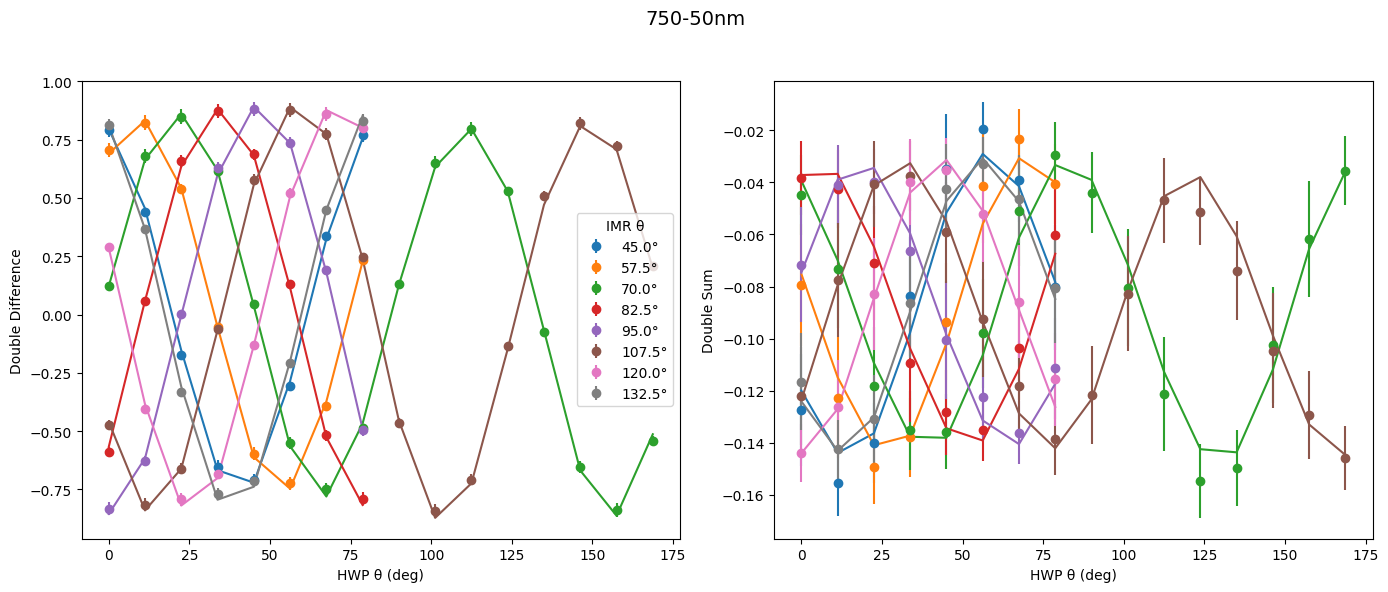

After p0: {'dichroic': {'phi': 0.012865154142167115, 'epsilon': 0.0026643152678419036, 'theta': 3.9621774260927634}, 'flc': {'phi': 3.2641936010510673, 'delta_theta': 0.4240516525047635}, 'optics': {'phi': 1.1469362605899835, 'epsilon': 0.06875940845505923, 'theta': -71.25287931463993}, 'image_rotator': {'phi': 3.076280920594426}, 'hwp': {'phi': 3.0481611339107317, 'delta_theta': 1.0136948241259875}, 'lp': {'theta': 2.6717853206993274}}
Before p0: {'dichroic': {'phi': 0.012865154142167115, 'epsilon': 0.0026643152678419036, 'theta': 3.9621774260927634}, 'flc': {'phi': 3.2641936010510673, 'delta_theta': 0.4240516525047635}, 'optics': {'phi': 1.1469362605899835, 'epsilon': 0.06875940845505923, 'theta': -71.25287931463993}, 'image_rotator': {'phi': 3.076280920594426}, 'hwp': {'phi': 3.0481611339107317, 'delta_theta': 1.0136948241259875}, 'lp': {'theta': 2.6717853206993274}}
Iteration #: 5
logl_value: 25.496233687471445
Best Fit Parameters: [ 1.51286822e-01  3.15119958e-03  5.36140123e+00  

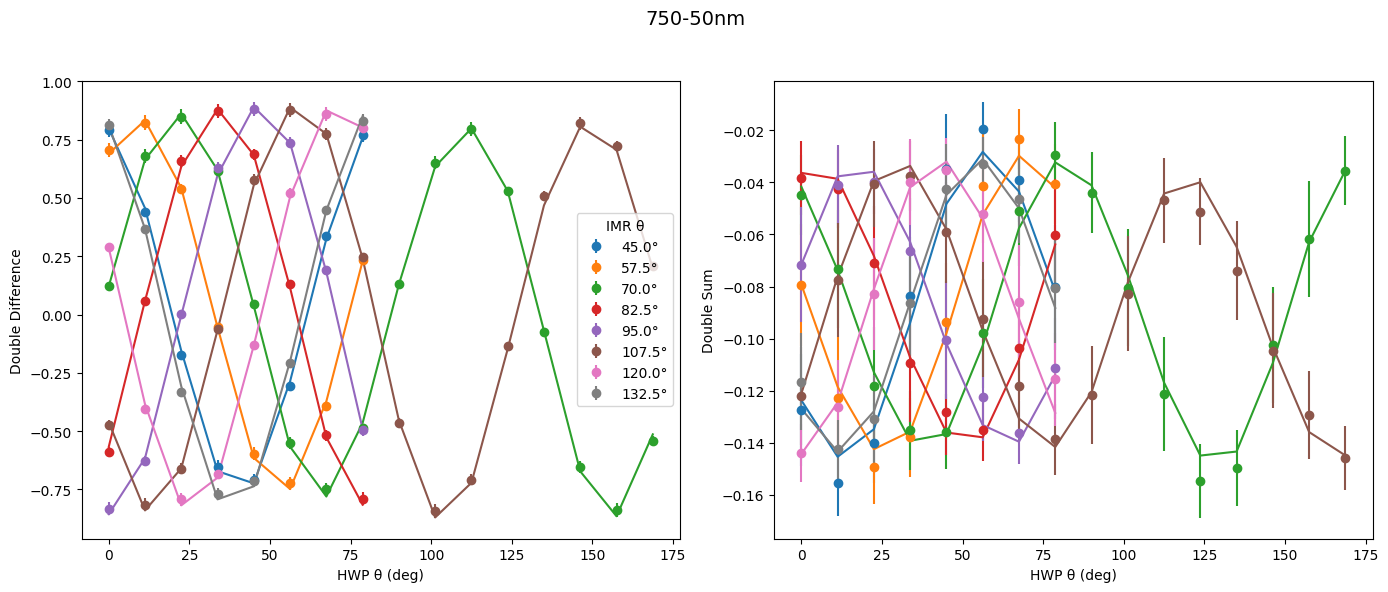

After p0: {'dichroic': {'phi': 0.15128682239998958, 'epsilon': 0.003151199580665785, 'theta': 5.36140123116099}, 'flc': {'phi': 3.21614768283026, 'delta_theta': 1.3326230822381189}, 'optics': {'phi': 1.0645844238782467, 'epsilon': 0.06947717021615205, 'theta': -69.02656388704088}, 'image_rotator': {'phi': 3.079863214210632}, 'hwp': {'phi': 3.0470873961028344, 'delta_theta': 0.3838931558805607}, 'lp': {'theta': 2.7625756741593746}}
Before p0: {'dichroic': {'phi': 0.15128682239998958, 'epsilon': 0.003151199580665785, 'theta': 5.36140123116099}, 'flc': {'phi': 3.21614768283026, 'delta_theta': 1.3326230822381189}, 'optics': {'phi': 1.0645844238782467, 'epsilon': 0.06947717021615205, 'theta': -69.02656388704088}, 'image_rotator': {'phi': 3.079863214210632}, 'hwp': {'phi': 3.0470873961028344, 'delta_theta': 0.3838931558805607}, 'lp': {'theta': 2.7625756741593746}}
Iteration #: 6
logl_value: 24.96612876539526
Best Fit Parameters: [ 8.68055375e-01  2.73929834e-03  2.78967937e+00  3.12680262e+0

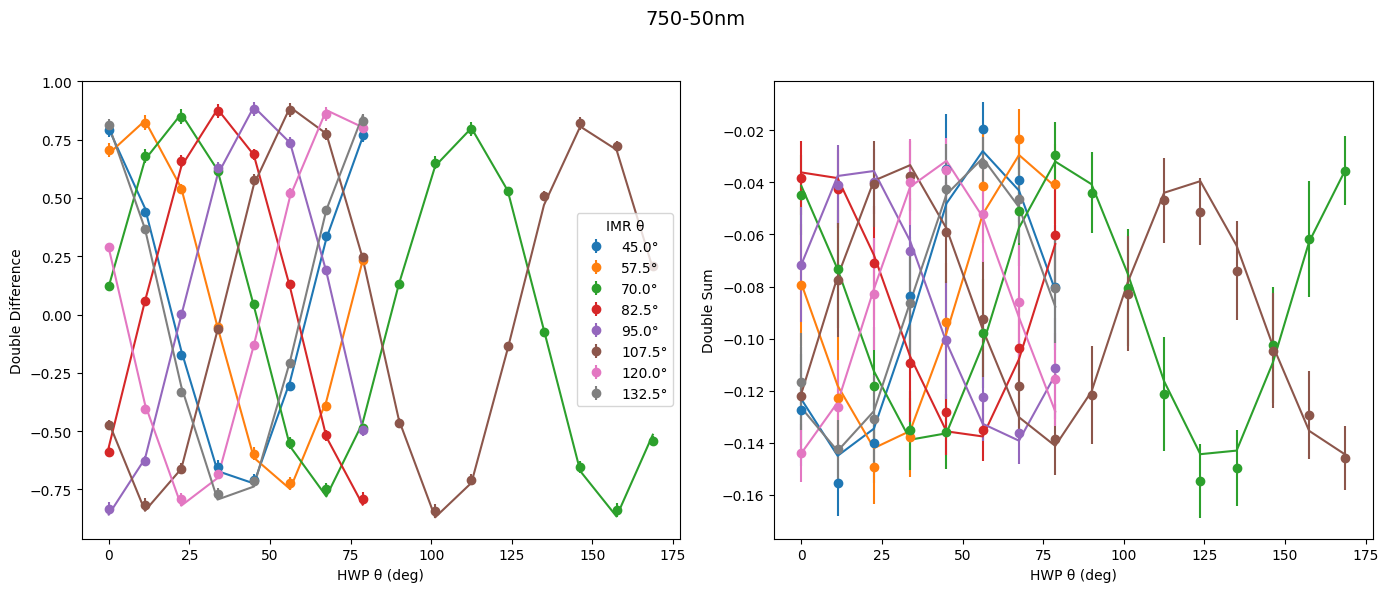

After p0: {'dichroic': {'phi': 0.8680553746151434, 'epsilon': 0.0027392983372009315, 'theta': 2.7896793739041312}, 'flc': {'phi': 3.126802621360609, 'delta_theta': 1.3928004524534332}, 'optics': {'phi': 1.0206027804273399, 'epsilon': 0.06993873840994899, 'theta': -70.14202720029553}, 'image_rotator': {'phi': 3.079323916693731}, 'hwp': {'phi': 3.0473334678207493, 'delta_theta': 1.4098979961052494}, 'lp': {'theta': 4.407784557416132}}
Before p0: {'dichroic': {'phi': 0.8680553746151434, 'epsilon': 0.0027392983372009315, 'theta': 2.7896793739041312}, 'flc': {'phi': 3.126802621360609, 'delta_theta': 1.3928004524534332}, 'optics': {'phi': 1.0206027804273399, 'epsilon': 0.06993873840994899, 'theta': -70.14202720029553}, 'image_rotator': {'phi': 3.079323916693731}, 'hwp': {'phi': 3.0473334678207493, 'delta_theta': 1.4098979961052494}, 'lp': {'theta': 4.407784557416132}}
Iteration #: 7
logl_value: 24.80742926415406
Best Fit Parameters: [ 1.10467396e+00  2.60454305e-03  2.45660864e+00  3.1209019

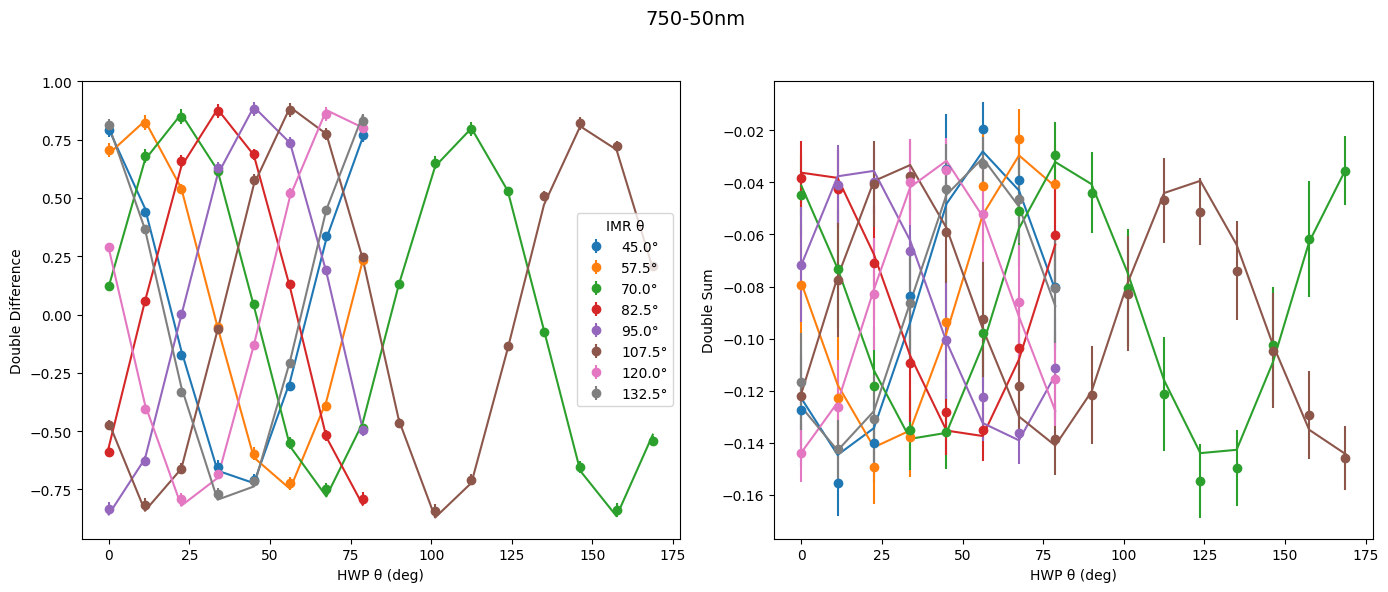

After p0: {'dichroic': {'phi': 1.104673958522075, 'epsilon': 0.0026045430473520684, 'theta': 2.4566086433018635}, 'flc': {'phi': 3.120901944482366, 'delta_theta': 1.0070093928703348}, 'optics': {'phi': 1.0222967433129697, 'epsilon': 0.06939458374915147, 'theta': -71.29861026613699}, 'image_rotator': {'phi': 3.0786255366630755}, 'hwp': {'phi': 3.048070991966015, 'delta_theta': 2.184799965069291}, 'lp': {'theta': 4.901079788967248}}
Before p0: {'dichroic': {'phi': 1.104673958522075, 'epsilon': 0.0026045430473520684, 'theta': 2.4566086433018635}, 'flc': {'phi': 3.120901944482366, 'delta_theta': 1.0070093928703348}, 'optics': {'phi': 1.0222967433129697, 'epsilon': 0.06939458374915147, 'theta': -71.29861026613699}, 'image_rotator': {'phi': 3.0786255366630755}, 'hwp': {'phi': 3.048070991966015, 'delta_theta': 2.184799965069291}, 'lp': {'theta': 4.901079788967248}}
Iteration #: 8
logl_value: 24.77626784363103
Best Fit Parameters: [ 1.17748029e+00  2.64641826e-03  2.61309929e+00  3.10578664e+0

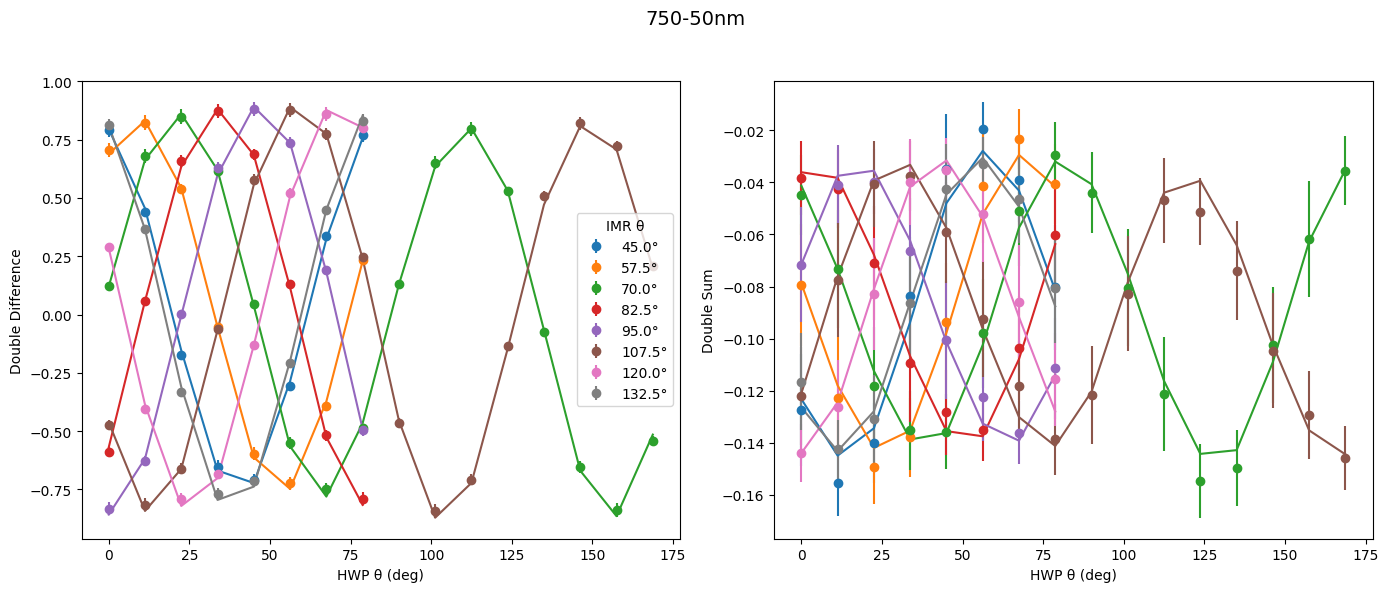

After p0: {'dichroic': {'phi': 1.177480291415522, 'epsilon': 0.0026464182557240454, 'theta': 2.613099289013821}, 'flc': {'phi': 3.1057866425048157, 'delta_theta': 0.9636293658150623}, 'optics': {'phi': 1.0058481611597943, 'epsilon': 0.06962171513557461, 'theta': -71.59687509571279}, 'image_rotator': {'phi': 3.0777886019459952}, 'hwp': {'phi': 3.048511754967647, 'delta_theta': 2.4126716131753794}, 'lp': {'theta': 4.979953760113547}}
Before p0: {'dichroic': {'phi': 1.177480291415522, 'epsilon': 0.0026464182557240454, 'theta': 2.613099289013821}, 'flc': {'phi': 3.1057866425048157, 'delta_theta': 0.9636293658150623}, 'optics': {'phi': 1.0058481611597943, 'epsilon': 0.06962171513557461, 'theta': -71.59687509571279}, 'image_rotator': {'phi': 3.0777886019459952}, 'hwp': {'phi': 3.048511754967647, 'delta_theta': 2.4126716131753794}, 'lp': {'theta': 4.979953760113547}}
Iteration #: 9
logl_value: 24.770808763090486
Best Fit Parameters: [ 1.24709667e+00  2.63334153e-03  2.42532970e+00  3.11382460

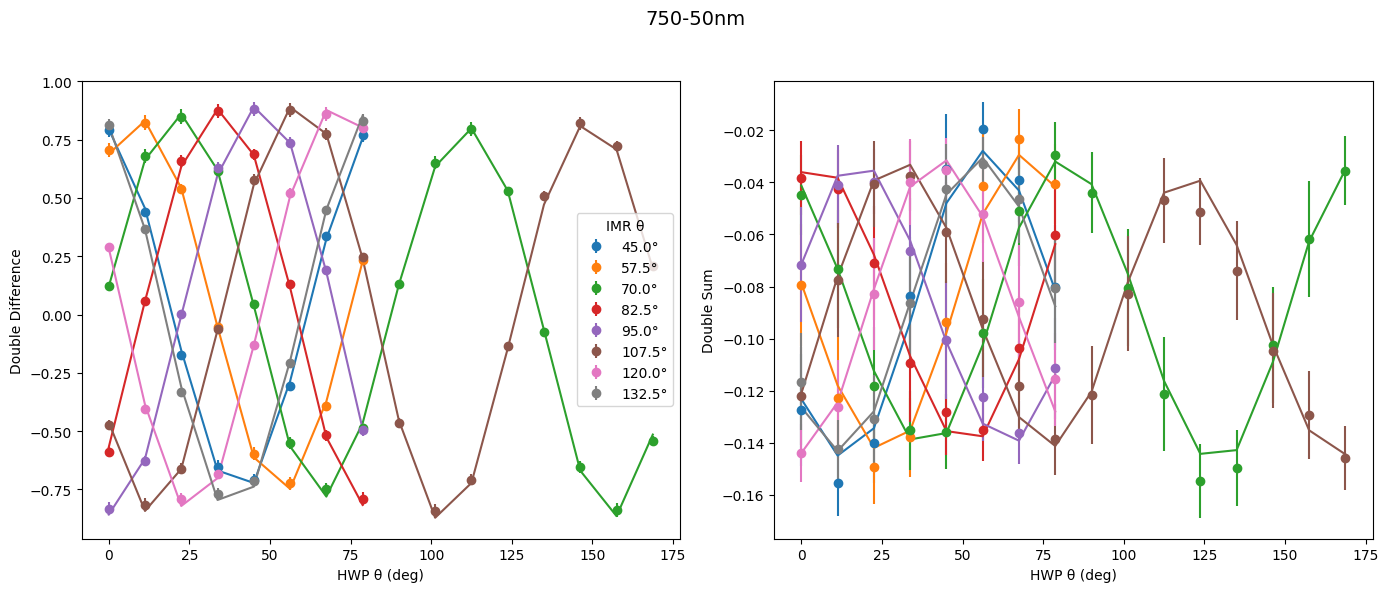

After p0: {'dichroic': {'phi': 1.2470966692474503, 'epsilon': 0.0026333415324825086, 'theta': 2.4253297023229337}, 'flc': {'phi': 3.113824599142788, 'delta_theta': 0.9126036246479421}, 'optics': {'phi': 1.013456069052876, 'epsilon': 0.06959978331791433, 'theta': -71.75436409706703}, 'image_rotator': {'phi': 3.0775689732030234}, 'hwp': {'phi': 3.048610340450171, 'delta_theta': 2.4963728534346306}, 'lp': {'theta': 4.999168067472647}}
Before p0: {'dichroic': {'phi': 1.2470966692474503, 'epsilon': 0.0026333415324825086, 'theta': 2.4253297023229337}, 'flc': {'phi': 3.113824599142788, 'delta_theta': 0.9126036246479421}, 'optics': {'phi': 1.013456069052876, 'epsilon': 0.06959978331791433, 'theta': -71.75436409706703}, 'image_rotator': {'phi': 3.0775689732030234}, 'hwp': {'phi': 3.048610340450171, 'delta_theta': 2.4963728534346306}, 'lp': {'theta': 4.999168067472647}}
Iteration #: 10
logl_value: 24.77070851079986
Best Fit Parameters: [ 1.25232267e+00  2.63137709e-03  2.42724101e+00  3.11337648

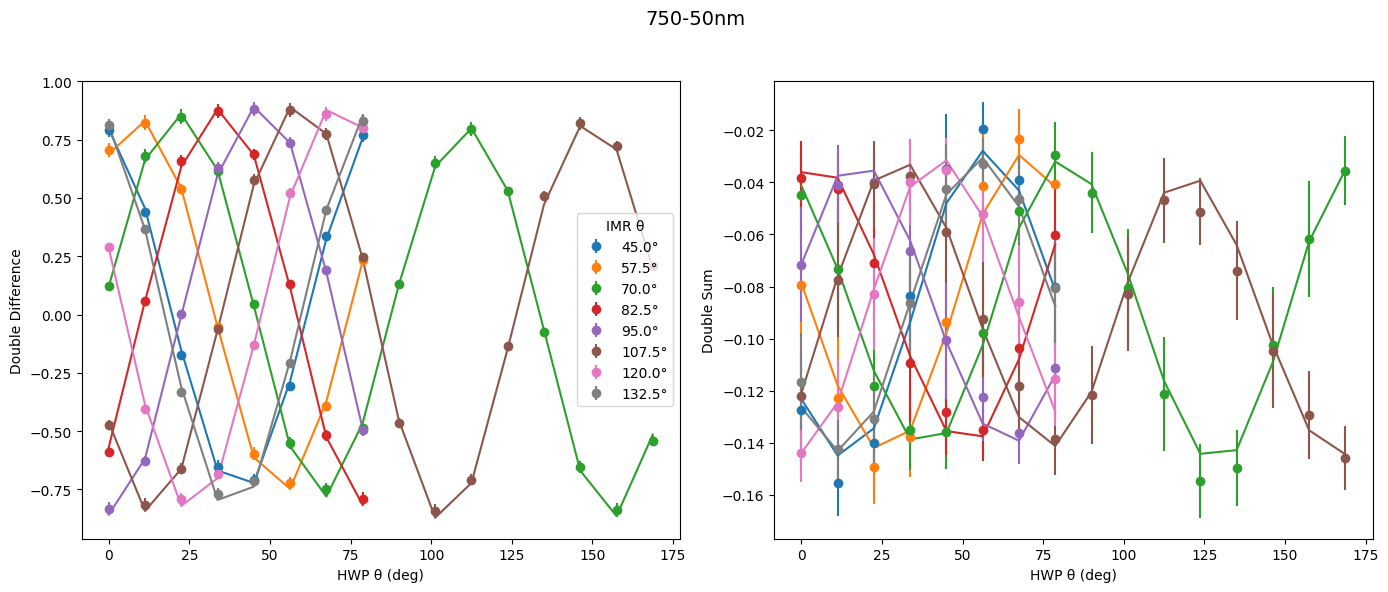

After p0: {'dichroic': {'phi': 1.2523226678820802, 'epsilon': 0.0026313770890577823, 'theta': 2.4272410130546556}, 'flc': {'phi': 3.1133764762763696, 'delta_theta': 0.9107499699398798}, 'optics': {'phi': 1.0133139132744233, 'epsilon': 0.06959865378331118, 'theta': -71.77314184135673}, 'image_rotator': {'phi': 3.077545593312649}, 'hwp': {'phi': 3.048624753242815, 'delta_theta': 2.503568098159077}, 'lp': {'theta': 4.999999962005257}}
Before p0: {'dichroic': {'phi': 1.2523226678820802, 'epsilon': 0.0026313770890577823, 'theta': 2.4272410130546556}, 'flc': {'phi': 3.1133764762763696, 'delta_theta': 0.9107499699398798}, 'optics': {'phi': 1.0133139132744233, 'epsilon': 0.06959865378331118, 'theta': -71.77314184135673}, 'image_rotator': {'phi': 3.077545593312649}, 'hwp': {'phi': 3.048624753242815, 'delta_theta': 2.503568098159077}, 'lp': {'theta': 4.999999962005257}}
Iteration #: 11
logl_value: 24.769668433188933
Best Fit Parameters: [ 1.36746804e+00  2.62907775e-03  2.35792364e+00  3.1129413

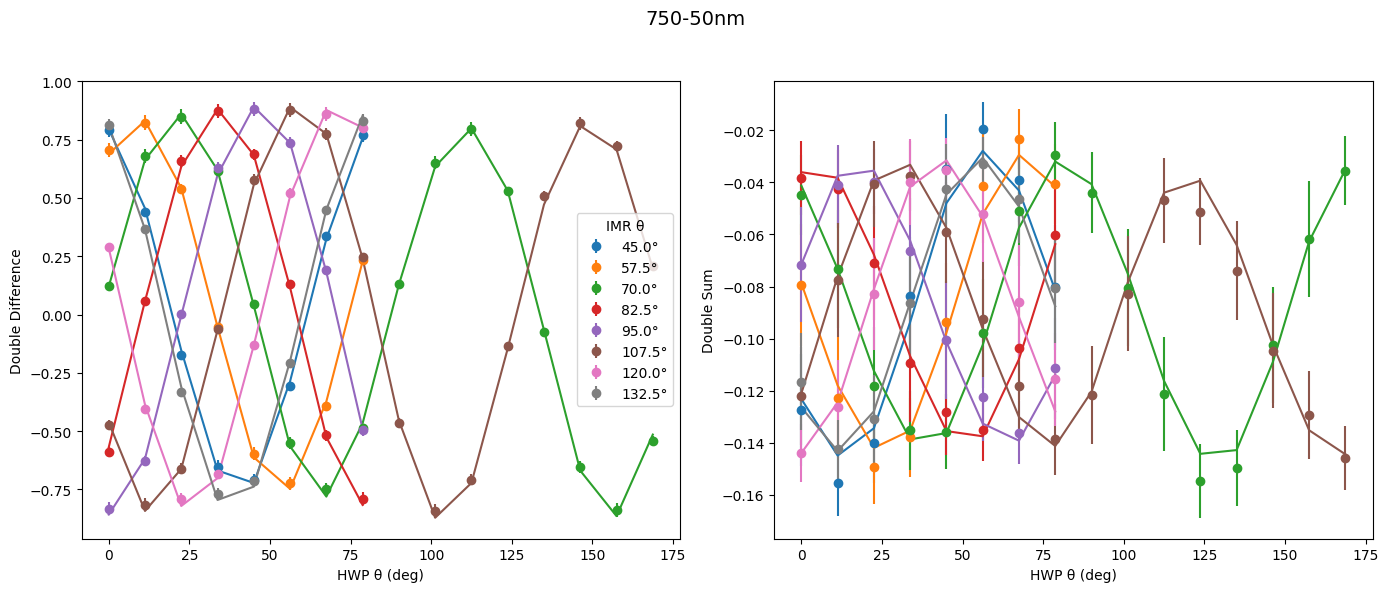

After p0: {'dichroic': {'phi': 1.3674680408789157, 'epsilon': 0.0026290777528499712, 'theta': 2.3579236397035217}, 'flc': {'phi': 3.1129413243811013, 'delta_theta': 1.0224084765269212}, 'optics': {'phi': 1.0129411692859365, 'epsilon': 0.06960874195761765, 'theta': -71.76534264520645}, 'image_rotator': {'phi': 3.0775468991759887}, 'hwp': {'phi': 3.0486481925389572, 'delta_theta': 2.4985750164946636}, 'lp': {'theta': 4.9997802041152735}}
Before p0: {'dichroic': {'phi': 1.3674680408789157, 'epsilon': 0.0026290777528499712, 'theta': 2.3579236397035217}, 'flc': {'phi': 3.1129413243811013, 'delta_theta': 1.0224084765269212}, 'optics': {'phi': 1.0129411692859365, 'epsilon': 0.06960874195761765, 'theta': -71.76534264520645}, 'image_rotator': {'phi': 3.0775468991759887}, 'hwp': {'phi': 3.0486481925389572, 'delta_theta': 2.4985750164946636}, 'lp': {'theta': 4.9997802041152735}}
Iteration #: 12
logl_value: 24.768444868290608
Best Fit Parameters: [ 1.50204286e+00  2.61520396e-03  2.32908335e+00  3

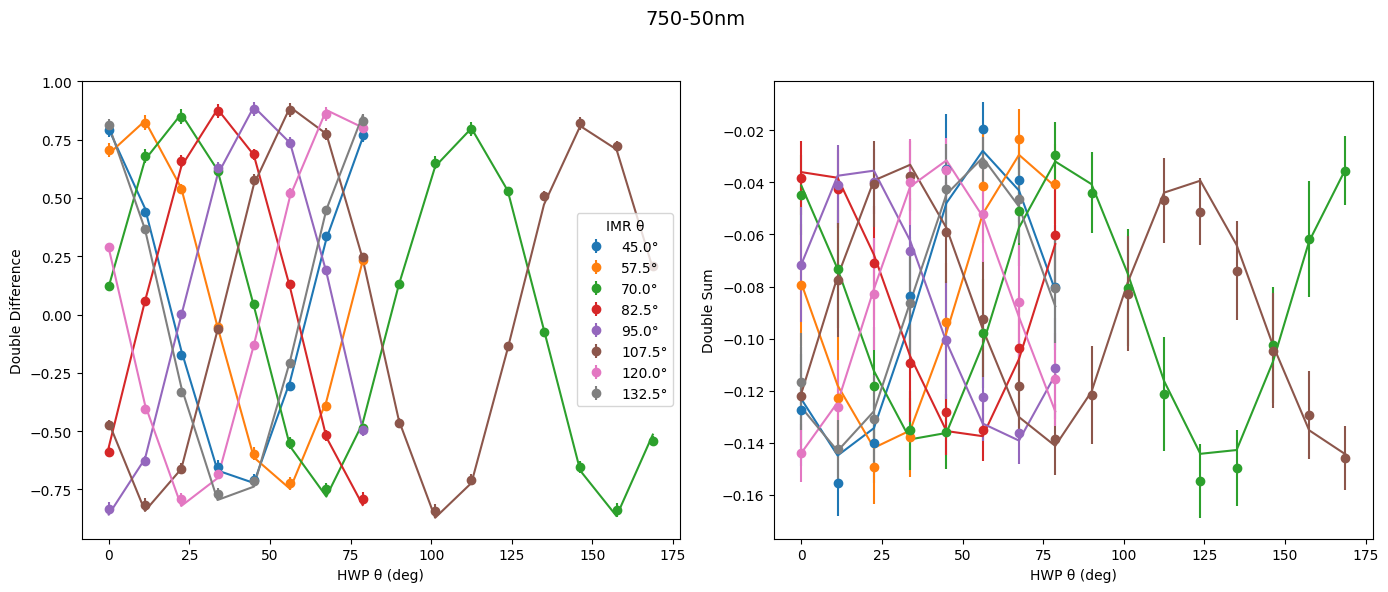

After p0: {'dichroic': {'phi': 1.5020428644353925, 'epsilon': 0.0026152039646664587, 'theta': 2.3290833537993123}, 'flc': {'phi': 3.1118077776373676, 'delta_theta': 1.1846556963093335}, 'optics': {'phi': 1.0113432024065272, 'epsilon': 0.06955526741070087, 'theta': -71.724883038125}, 'image_rotator': {'phi': 3.077499837350885}, 'hwp': {'phi': 3.0485894326737215, 'delta_theta': 2.483138898265845}, 'lp': {'theta': 4.999997090938955}}
Before p0: {'dichroic': {'phi': 1.5020428644353925, 'epsilon': 0.0026152039646664587, 'theta': 2.3290833537993123}, 'flc': {'phi': 3.1118077776373676, 'delta_theta': 1.1846556963093335}, 'optics': {'phi': 1.0113432024065272, 'epsilon': 0.06955526741070087, 'theta': -71.724883038125}, 'image_rotator': {'phi': 3.077499837350885}, 'hwp': {'phi': 3.0485894326737215, 'delta_theta': 2.483138898265845}, 'lp': {'theta': 4.999997090938955}}
Iteration #: 13
logl_value: 24.76526410702481
Best Fit Parameters: [ 1.80014441e+00  2.62710849e-03  2.43761221e+00  3.10767025e+

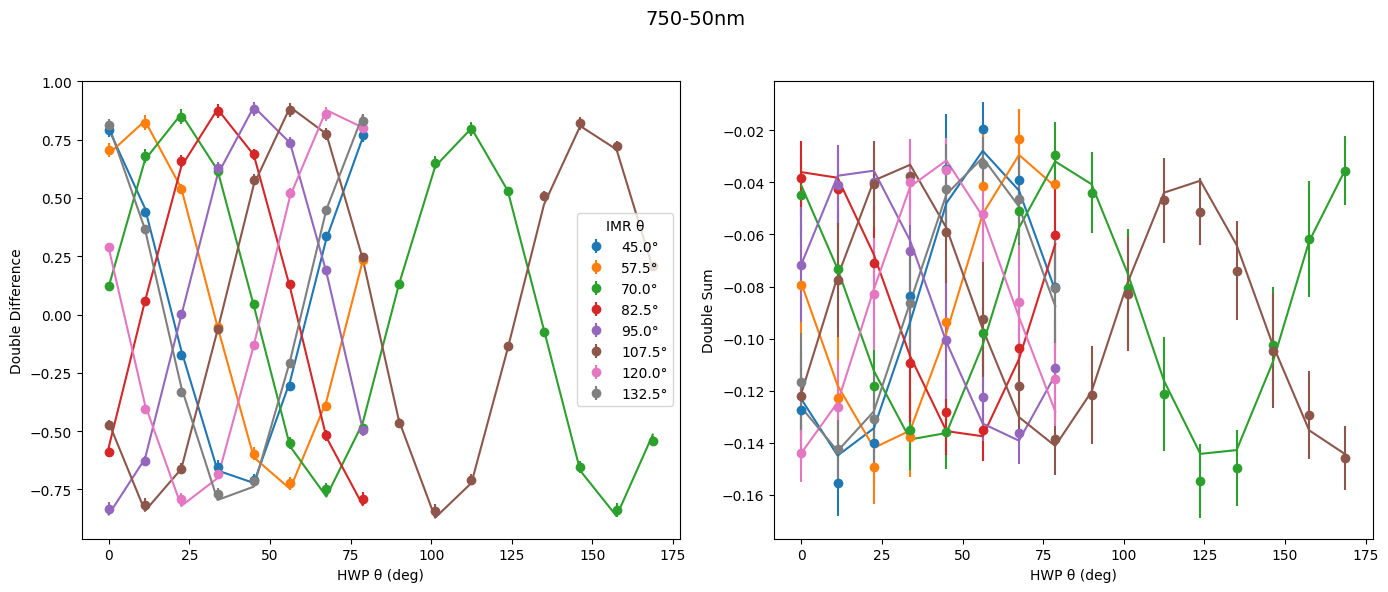

After p0: {'dichroic': {'phi': 1.8001444120040775, 'epsilon': 0.0026271084922981445, 'theta': 2.437612210088342}, 'flc': {'phi': 3.1076702458124874, 'delta_theta': 1.591898691616377}, 'optics': {'phi': 1.0079027397362204, 'epsilon': 0.06962731481371875, 'theta': -71.73373418106081}, 'image_rotator': {'phi': 3.077547776605604}, 'hwp': {'phi': 3.0486247820957573, 'delta_theta': 2.47601254047144}, 'lp': {'theta': 4.9886679871257265}}
Before p0: {'dichroic': {'phi': 1.8001444120040775, 'epsilon': 0.0026271084922981445, 'theta': 2.437612210088342}, 'flc': {'phi': 3.1076702458124874, 'delta_theta': 1.591898691616377}, 'optics': {'phi': 1.0079027397362204, 'epsilon': 0.06962731481371875, 'theta': -71.73373418106081}, 'image_rotator': {'phi': 3.077547776605604}, 'hwp': {'phi': 3.0486247820957573, 'delta_theta': 2.47601254047144}, 'lp': {'theta': 4.9886679871257265}}
Iteration #: 14
logl_value: 24.763071505452857
Best Fit Parameters: [ 1.90231589e+00  2.63316380e-03  2.48124050e+00  3.10942986e

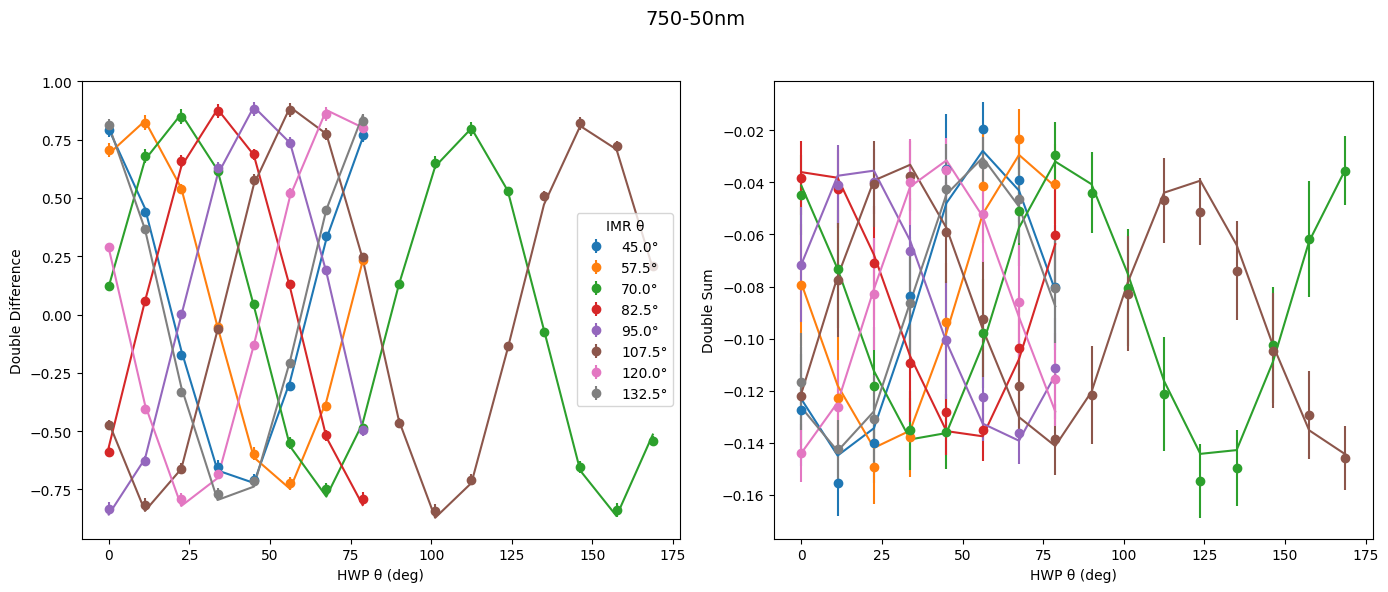

After p0: {'dichroic': {'phi': 1.9023158924347516, 'epsilon': 0.002633163795807695, 'theta': 2.4812405025316213}, 'flc': {'phi': 3.1094298596918843, 'delta_theta': 1.672600823944899}, 'optics': {'phi': 1.0099040071638745, 'epsilon': 0.06961197897395399, 'theta': -71.87499347318473}, 'image_rotator': {'phi': 3.077445650016136}, 'hwp': {'phi': 3.0487039768967303, 'delta_theta': 2.547148409536028}, 'lp': {'theta': 4.999979930812966}}
Before p0: {'dichroic': {'phi': 1.9023158924347516, 'epsilon': 0.002633163795807695, 'theta': 2.4812405025316213}, 'flc': {'phi': 3.1094298596918843, 'delta_theta': 1.672600823944899}, 'optics': {'phi': 1.0099040071638745, 'epsilon': 0.06961197897395399, 'theta': -71.87499347318473}, 'image_rotator': {'phi': 3.077445650016136}, 'hwp': {'phi': 3.0487039768967303, 'delta_theta': 2.547148409536028}, 'lp': {'theta': 4.999979930812966}}
Iteration #: 15
logl_value: 24.76267584725362
Best Fit Parameters: [ 1.89925296e+00  2.64552350e-03  2.49316256e+00  3.10840882e+

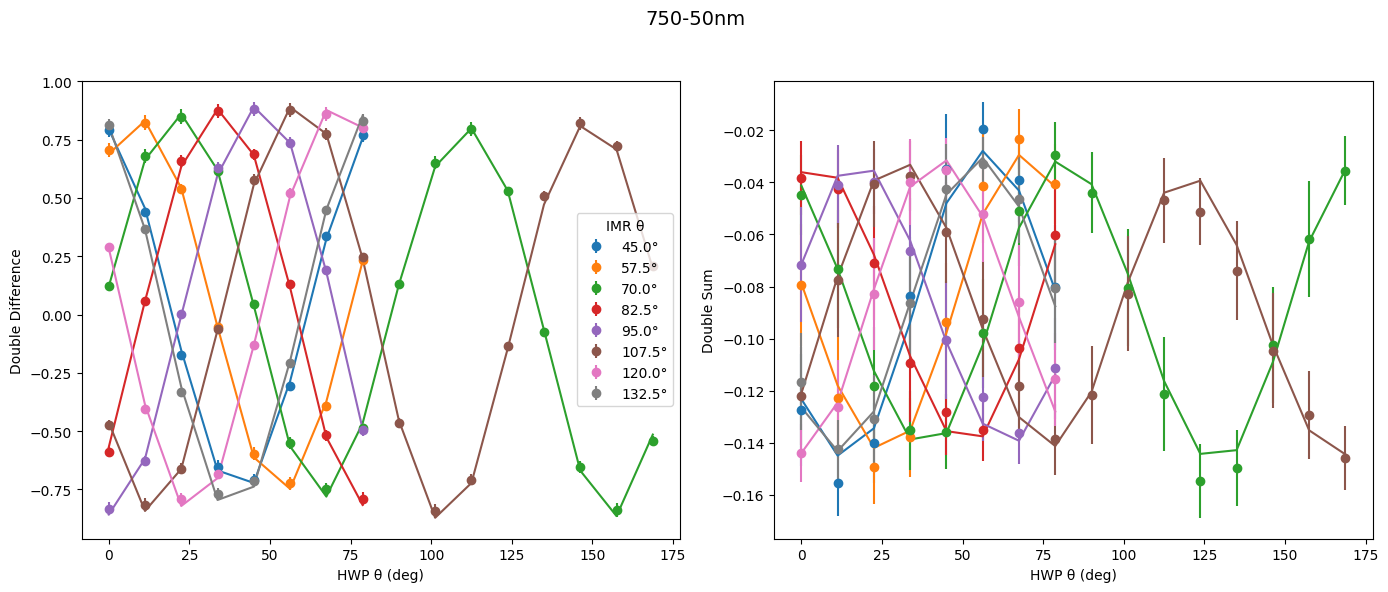

After p0: {'dichroic': {'phi': 1.8992529589895013, 'epsilon': 0.002645523500941295, 'theta': 2.4931625584302815}, 'flc': {'phi': 3.1084088189405277, 'delta_theta': 1.69362557447056}, 'optics': {'phi': 1.0092261285861515, 'epsilon': 0.06958607427122385, 'theta': -71.84574792707005}, 'image_rotator': {'phi': 3.0774845397578305}, 'hwp': {'phi': 3.0486465243637415, 'delta_theta': 2.5277910017790806}, 'lp': {'theta': 4.998947768620043}}
Before p0: {'dichroic': {'phi': 1.8992529589895013, 'epsilon': 0.002645523500941295, 'theta': 2.4931625584302815}, 'flc': {'phi': 3.1084088189405277, 'delta_theta': 1.69362557447056}, 'optics': {'phi': 1.0092261285861515, 'epsilon': 0.06958607427122385, 'theta': -71.84574792707005}, 'image_rotator': {'phi': 3.0774845397578305}, 'hwp': {'phi': 3.0486465243637415, 'delta_theta': 2.5277910017790806}, 'lp': {'theta': 4.998947768620043}}
Iteration #: 16
logl_value: 24.755694888233652
Best Fit Parameters: [ 2.17346133e+00  2.63228051e-03  2.84912785e+00  3.1087235

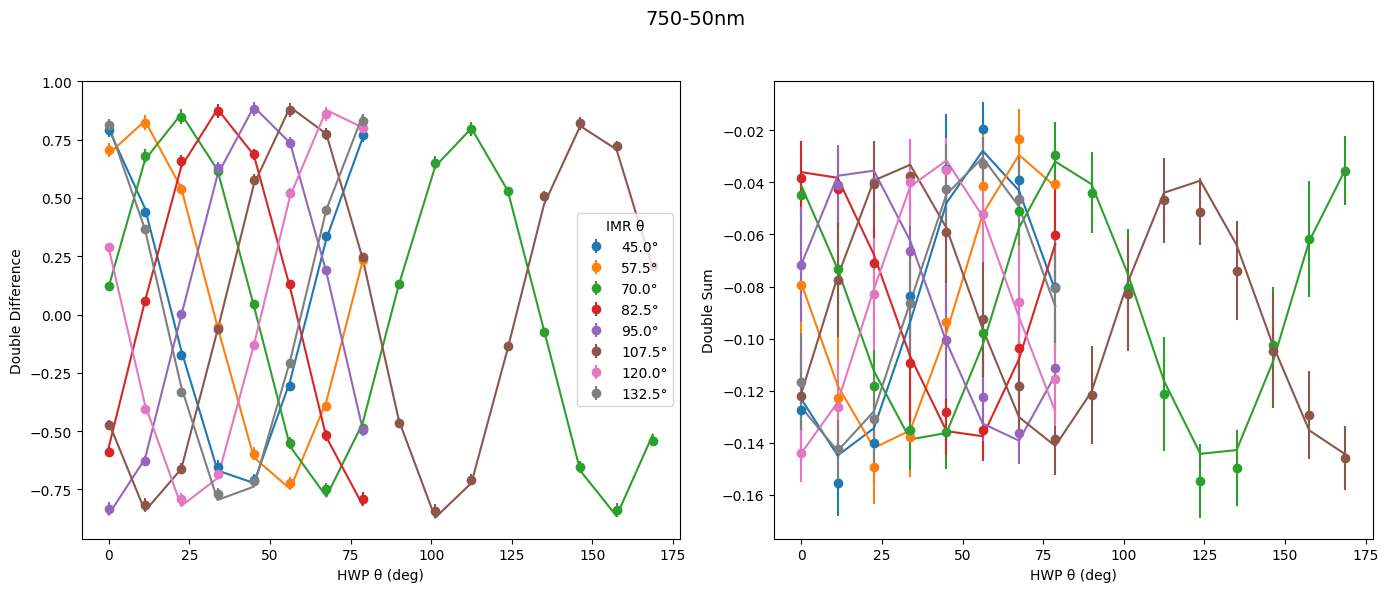

After p0: {'dichroic': {'phi': 2.173461333591403, 'epsilon': 0.0026322805094684994, 'theta': 2.849127854195827}, 'flc': {'phi': 3.1087235252364644, 'delta_theta': 2.304826463745769}, 'optics': {'phi': 1.0089945378688676, 'epsilon': 0.06955327717735582, 'theta': -71.79616045655808}, 'image_rotator': {'phi': 3.0774693947723692}, 'hwp': {'phi': 3.0485921759390076, 'delta_theta': 2.5020507777939516}, 'lp': {'theta': 4.999932044135832}}
Before p0: {'dichroic': {'phi': 2.173461333591403, 'epsilon': 0.0026322805094684994, 'theta': 2.849127854195827}, 'flc': {'phi': 3.1087235252364644, 'delta_theta': 2.304826463745769}, 'optics': {'phi': 1.0089945378688676, 'epsilon': 0.06955327717735582, 'theta': -71.79616045655808}, 'image_rotator': {'phi': 3.0774693947723692}, 'hwp': {'phi': 3.0485921759390076, 'delta_theta': 2.5020507777939516}, 'lp': {'theta': 4.999932044135832}}
Iteration #: 17
logl_value: 24.749895109511986
Best Fit Parameters: [ 2.30218008e+00  2.64521236e-03  3.23696947e+00  3.1031763

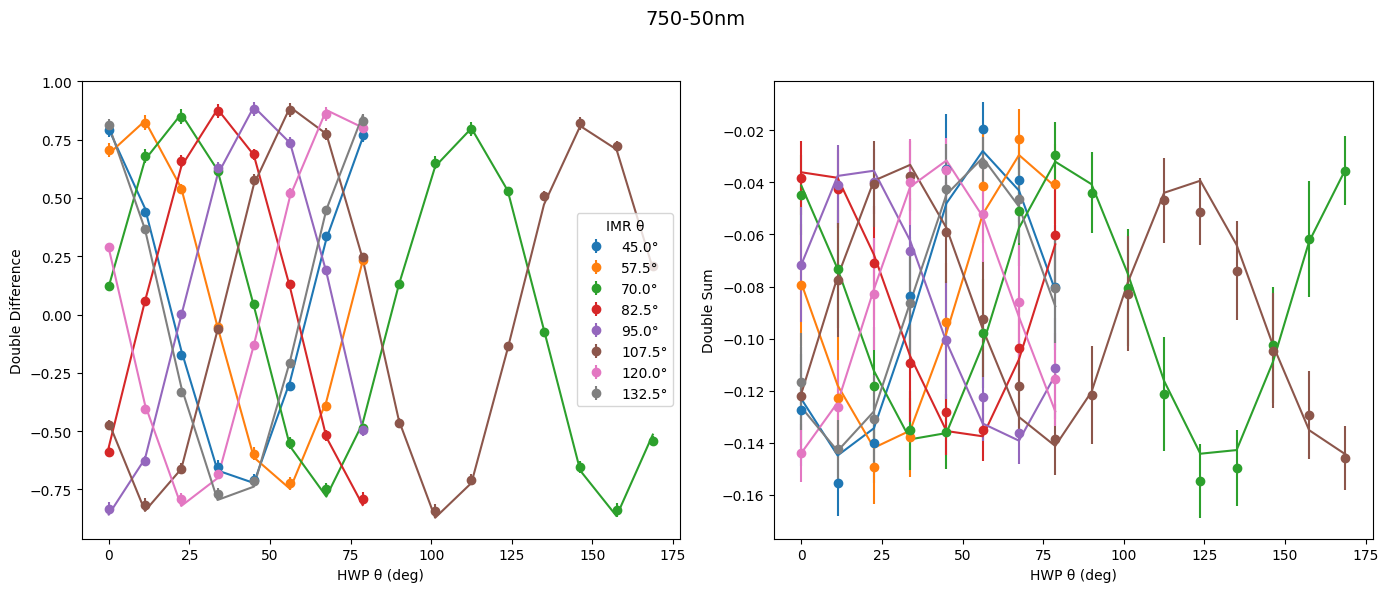

After p0: {'dichroic': {'phi': 2.3021800764659357, 'epsilon': 0.002645212360718071, 'theta': 3.2369694745688697}, 'flc': {'phi': 3.1031763215997827, 'delta_theta': 2.7532504847650703}, 'optics': {'phi': 1.0052240402262003, 'epsilon': 0.0695648767761676, 'theta': -71.84672315484153}, 'image_rotator': {'phi': 3.077581104205212}, 'hwp': {'phi': 3.048716689057289, 'delta_theta': 2.5057352802502475}, 'lp': {'theta': 4.999329099493888}}
Before p0: {'dichroic': {'phi': 2.3021800764659357, 'epsilon': 0.002645212360718071, 'theta': 3.2369694745688697}, 'flc': {'phi': 3.1031763215997827, 'delta_theta': 2.7532504847650703}, 'optics': {'phi': 1.0052240402262003, 'epsilon': 0.0695648767761676, 'theta': -71.84672315484153}, 'image_rotator': {'phi': 3.077581104205212}, 'hwp': {'phi': 3.048716689057289, 'delta_theta': 2.5057352802502475}, 'lp': {'theta': 4.999329099493888}}
Iteration #: 18
logl_value: 24.748976214207097
Best Fit Parameters: [ 2.34885253e+00  2.63326805e-03  3.37031505e+00  3.10379582e

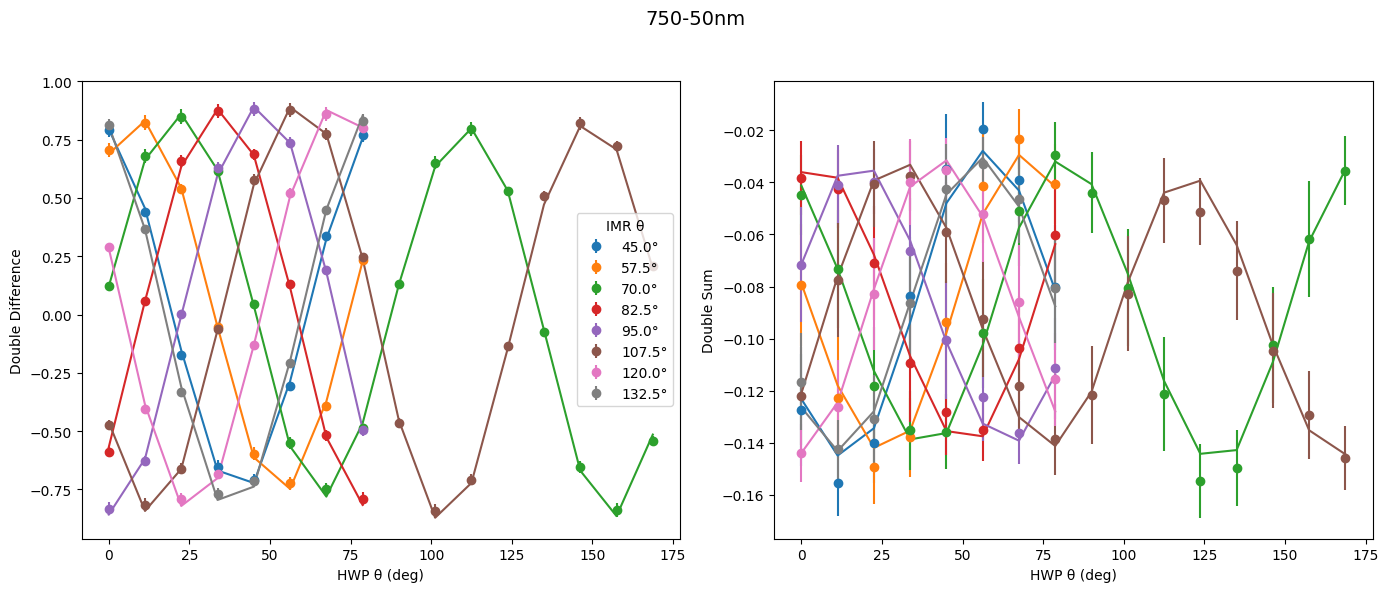

After p0: {'dichroic': {'phi': 2.3488525256026493, 'epsilon': 0.0026332680475607516, 'theta': 3.370315049006461}, 'flc': {'phi': 3.103795821964708, 'delta_theta': 2.9519698375736345}, 'optics': {'phi': 1.0049711239993542, 'epsilon': 0.06962758660514759, 'theta': -71.78073842297627}, 'image_rotator': {'phi': 3.077663591337462}, 'hwp': {'phi': 3.0487126136510474, 'delta_theta': 2.472570489232842}, 'lp': {'theta': 4.983924971856148}}
Before p0: {'dichroic': {'phi': 2.3488525256026493, 'epsilon': 0.0026332680475607516, 'theta': 3.370315049006461}, 'flc': {'phi': 3.103795821964708, 'delta_theta': 2.9519698375736345}, 'optics': {'phi': 1.0049711239993542, 'epsilon': 0.06962758660514759, 'theta': -71.78073842297627}, 'image_rotator': {'phi': 3.077663591337462}, 'hwp': {'phi': 3.0487126136510474, 'delta_theta': 2.472570489232842}, 'lp': {'theta': 4.983924971856148}}
Iteration #: 19
logl_value: 24.74166335815584
Best Fit Parameters: [ 2.49551983e+00  2.64259371e-03  3.88833275e+00  3.10781246e+

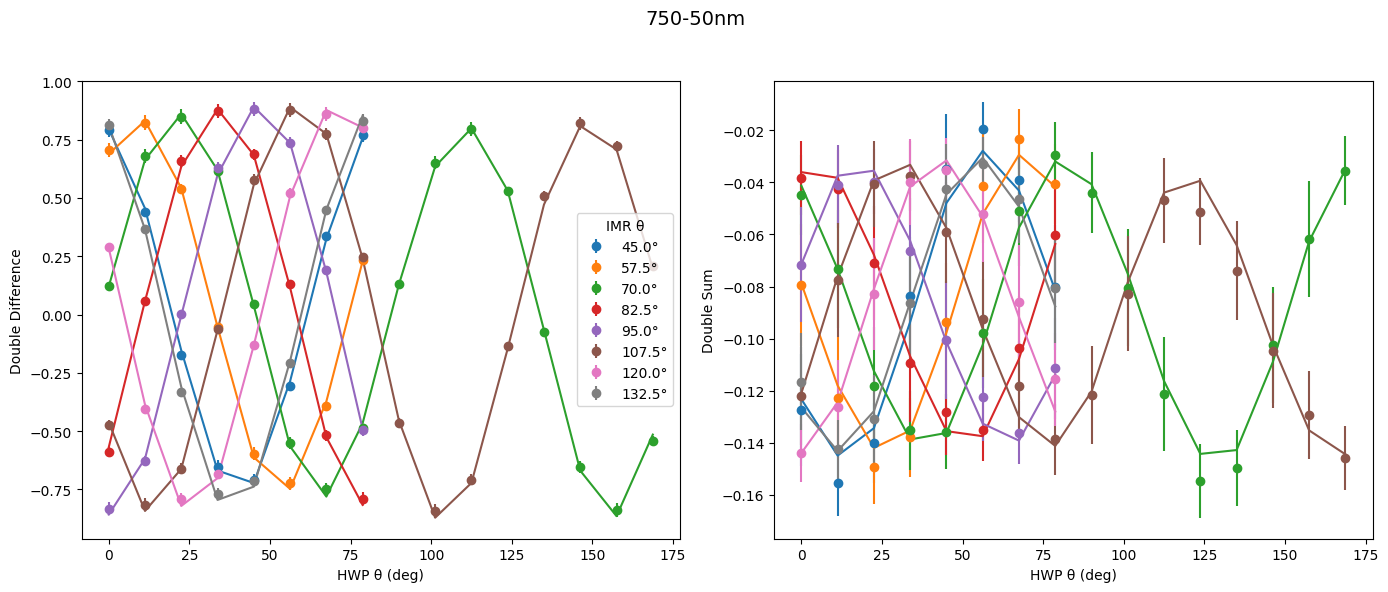

After p0: {'dichroic': {'phi': 2.495519834684824, 'epsilon': 0.002642593712316843, 'theta': 3.8883327543348103}, 'flc': {'phi': 3.1078124584749975, 'delta_theta': 3.620067519002496}, 'optics': {'phi': 1.0075381755440094, 'epsilon': 0.06958900021970929, 'theta': -71.70209349321578}, 'image_rotator': {'phi': 3.0777195151057075}, 'hwp': {'phi': 3.0485972424121828, 'delta_theta': 2.4462129632585627}, 'lp': {'theta': 4.997789457575829}}
Before p0: {'dichroic': {'phi': 2.495519834684824, 'epsilon': 0.002642593712316843, 'theta': 3.8883327543348103}, 'flc': {'phi': 3.1078124584749975, 'delta_theta': 3.620067519002496}, 'optics': {'phi': 1.0075381755440094, 'epsilon': 0.06958900021970929, 'theta': -71.70209349321578}, 'image_rotator': {'phi': 3.0777195151057075}, 'hwp': {'phi': 3.0485972424121828, 'delta_theta': 2.4462129632585627}, 'lp': {'theta': 4.997789457575829}}
Iteration #: 20
logl_value: 24.73731462800976
Best Fit Parameters: [ 2.48025532e+00  2.64836832e-03  4.00463397e+00  3.09801243

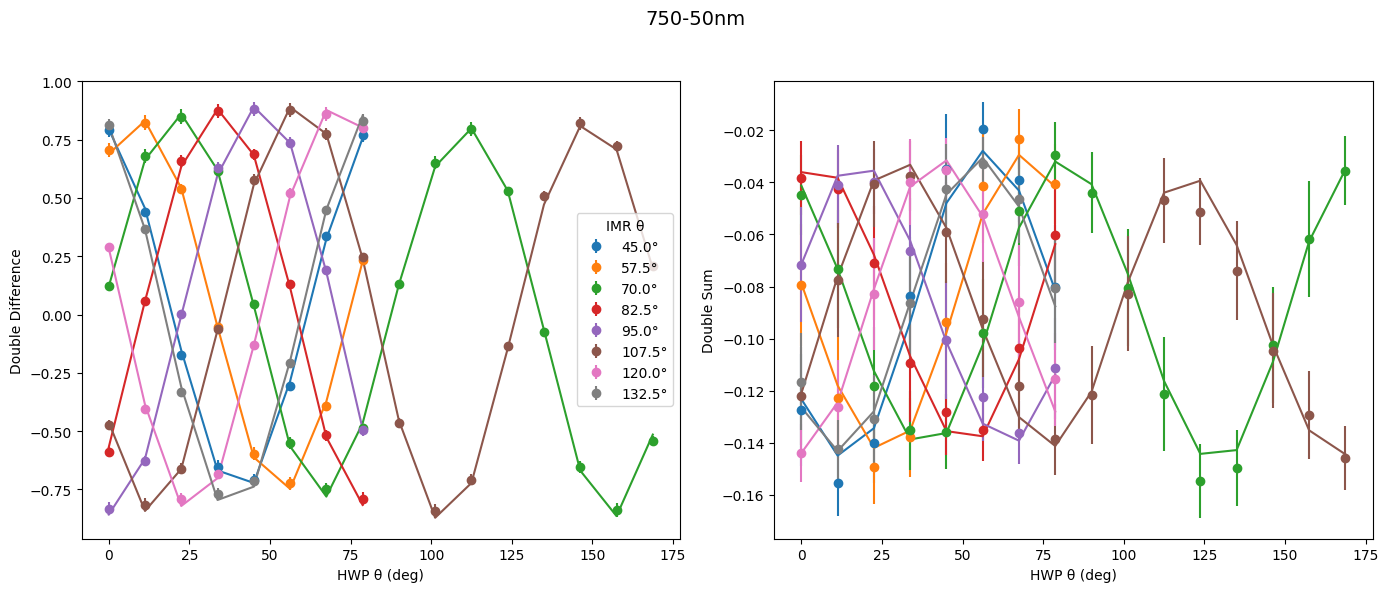

After p0: {'dichroic': {'phi': 2.4802553222840977, 'epsilon': 0.0026483683185991366, 'theta': 4.004633970090975}, 'flc': {'phi': 3.098012434799424, 'delta_theta': 3.616347944970281}, 'optics': {'phi': 0.9996070071808041, 'epsilon': 0.0695688380386083, 'theta': -71.88523165328218}, 'image_rotator': {'phi': 3.077434192765141}, 'hwp': {'phi': 3.048663440149639, 'delta_theta': 2.524183750704241}, 'lp': {'theta': 4.999933644901464}}
Before p0: {'dichroic': {'phi': 2.4802553222840977, 'epsilon': 0.0026483683185991366, 'theta': 4.004633970090975}, 'flc': {'phi': 3.098012434799424, 'delta_theta': 3.616347944970281}, 'optics': {'phi': 0.9996070071808041, 'epsilon': 0.0695688380386083, 'theta': -71.88523165328218}, 'image_rotator': {'phi': 3.077434192765141}, 'hwp': {'phi': 3.048663440149639, 'delta_theta': 2.524183750704241}, 'lp': {'theta': 4.999933644901464}}
Iteration #: 21
logl_value: 24.725978434983904
Best Fit Parameters: [ 2.59499003e+00  2.70141924e-03  4.90214828e+00  3.08866328e+00
  

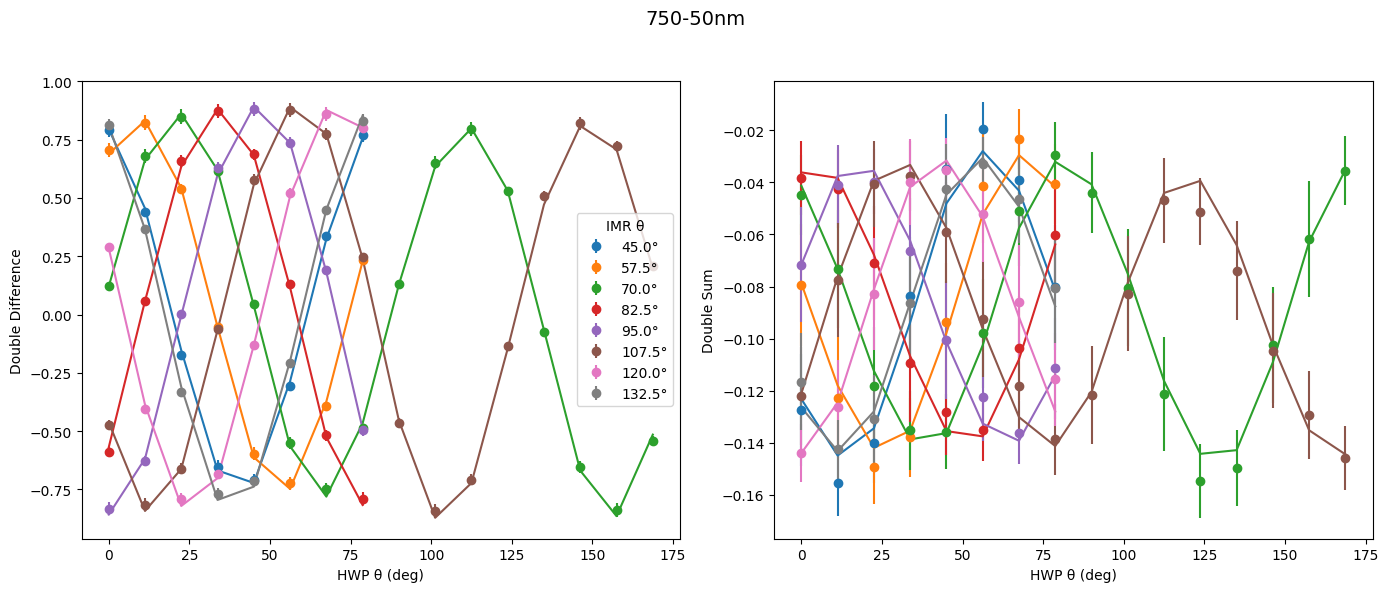

After p0: {'dichroic': {'phi': 2.5949900310369003, 'epsilon': 0.002701419239880924, 'theta': 4.902148278343569}, 'flc': {'phi': 3.088663277960835, 'delta_theta': 4.553865046018213}, 'optics': {'phi': 0.991894933082528, 'epsilon': 0.06948734199917828, 'theta': -71.96155229430394}, 'image_rotator': {'phi': 3.0775484615652395}, 'hwp': {'phi': 3.0485391939996003, 'delta_theta': 2.52049523134324}, 'lp': {'theta': 4.980897146114103}}
Before p0: {'dichroic': {'phi': 2.5949900310369003, 'epsilon': 0.002701419239880924, 'theta': 4.902148278343569}, 'flc': {'phi': 3.088663277960835, 'delta_theta': 4.553865046018213}, 'optics': {'phi': 0.991894933082528, 'epsilon': 0.06948734199917828, 'theta': -71.96155229430394}, 'image_rotator': {'phi': 3.0775484615652395}, 'hwp': {'phi': 3.0485391939996003, 'delta_theta': 2.52049523134324}, 'lp': {'theta': 4.980897146114103}}
Iteration #: 22
logl_value: 24.720233242411574
Best Fit Parameters: [ 2.63235391e+00  2.65505838e-03  5.38244795e+00  3.08125069e+00
  

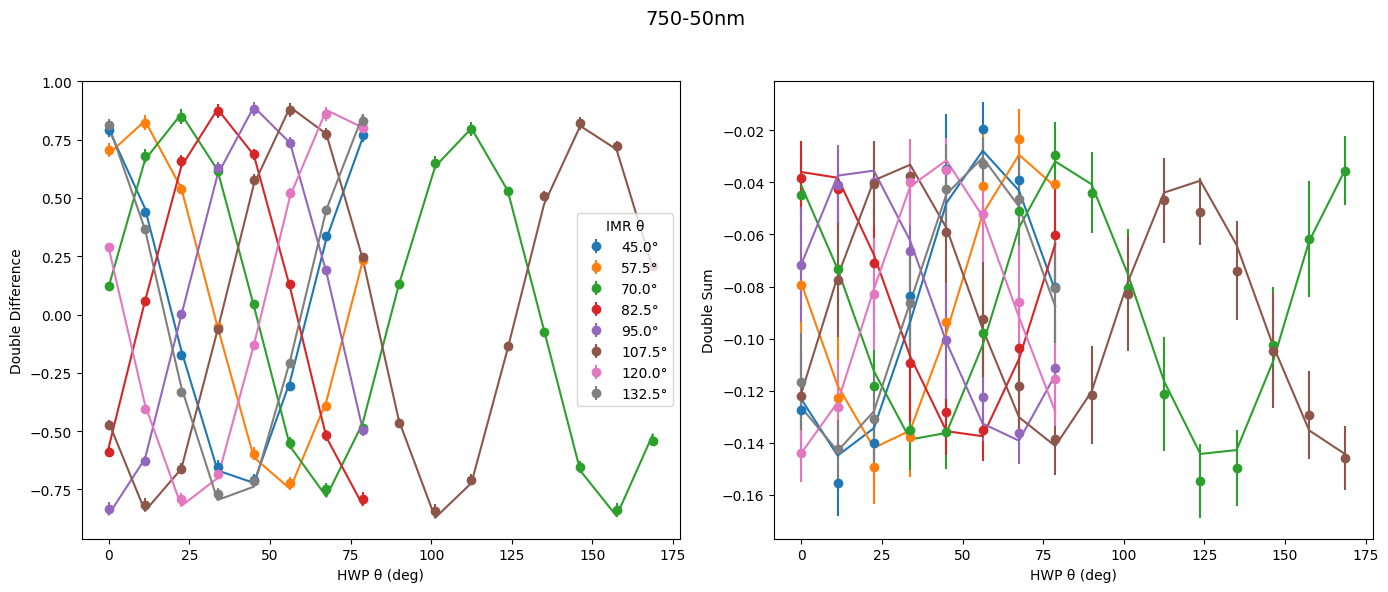

After p0: {'dichroic': {'phi': 2.632353909473524, 'epsilon': 0.0026550583767839158, 'theta': 5.382447953520501}, 'flc': {'phi': 3.081250689766353, 'delta_theta': 4.999450815051739}, 'optics': {'phi': 0.9829978431576069, 'epsilon': 0.06956186653410279, 'theta': -72.0378841413053}, 'image_rotator': {'phi': 3.0772655540138687}, 'hwp': {'phi': 3.0487687724219543, 'delta_theta': 2.5729507725387673}, 'lp': {'theta': 4.978467879380204}}
Before p0: {'dichroic': {'phi': 2.632353909473524, 'epsilon': 0.0026550583767839158, 'theta': 5.382447953520501}, 'flc': {'phi': 3.081250689766353, 'delta_theta': 4.999450815051739}, 'optics': {'phi': 0.9829978431576069, 'epsilon': 0.06956186653410279, 'theta': -72.0378841413053}, 'image_rotator': {'phi': 3.0772655540138687}, 'hwp': {'phi': 3.0487687724219543, 'delta_theta': 2.5729507725387673}, 'lp': {'theta': 4.978467879380204}}
Iteration #: 23
logl_value: 24.715016161786323
Best Fit Parameters: [ 2.64640669e+00  2.65943508e-03  5.31484010e+00  3.08982057e+0

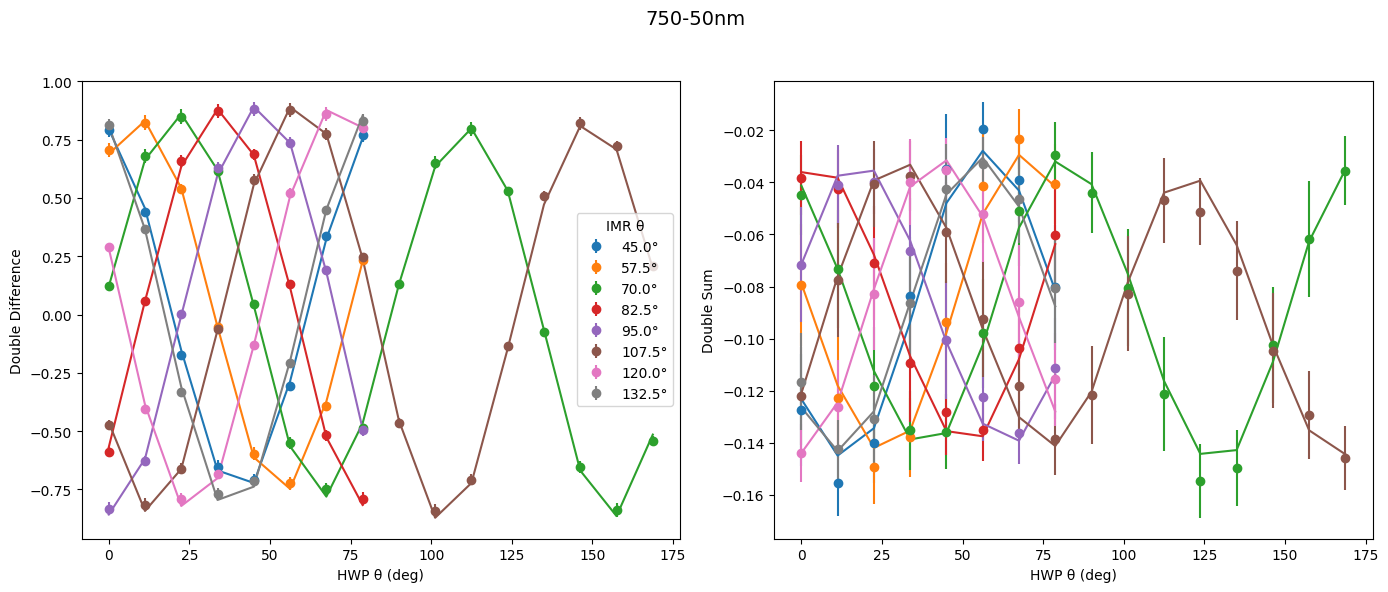

After p0: {'dichroic': {'phi': 2.6464066911467468, 'epsilon': 0.0026594350838255038, 'theta': 5.314840102687413}, 'flc': {'phi': 3.089820572396798, 'delta_theta': 4.999401219399438}, 'optics': {'phi': 0.9922493585759734, 'epsilon': 0.06954097123653782, 'theta': -71.96795081368805}, 'image_rotator': {'phi': 3.0774497203592803}, 'hwp': {'phi': 3.0486871160051083, 'delta_theta': 2.537426292945604}, 'lp': {'theta': 5.0}}
Before p0: {'dichroic': {'phi': 2.6464066911467468, 'epsilon': 0.0026594350838255038, 'theta': 5.314840102687413}, 'flc': {'phi': 3.089820572396798, 'delta_theta': 4.999401219399438}, 'optics': {'phi': 0.9922493585759734, 'epsilon': 0.06954097123653782, 'theta': -71.96795081368805}, 'image_rotator': {'phi': 3.0774497203592803}, 'hwp': {'phi': 3.0486871160051083, 'delta_theta': 2.537426292945604}, 'lp': {'theta': 5.0}}
Iteration #: 24
logl_value: 24.71501321067449
Best Fit Parameters: [ 2.64669969e+00  2.65981248e-03  5.31455606e+00  3.08994127e+00
  4.99936673e+00  9.92412

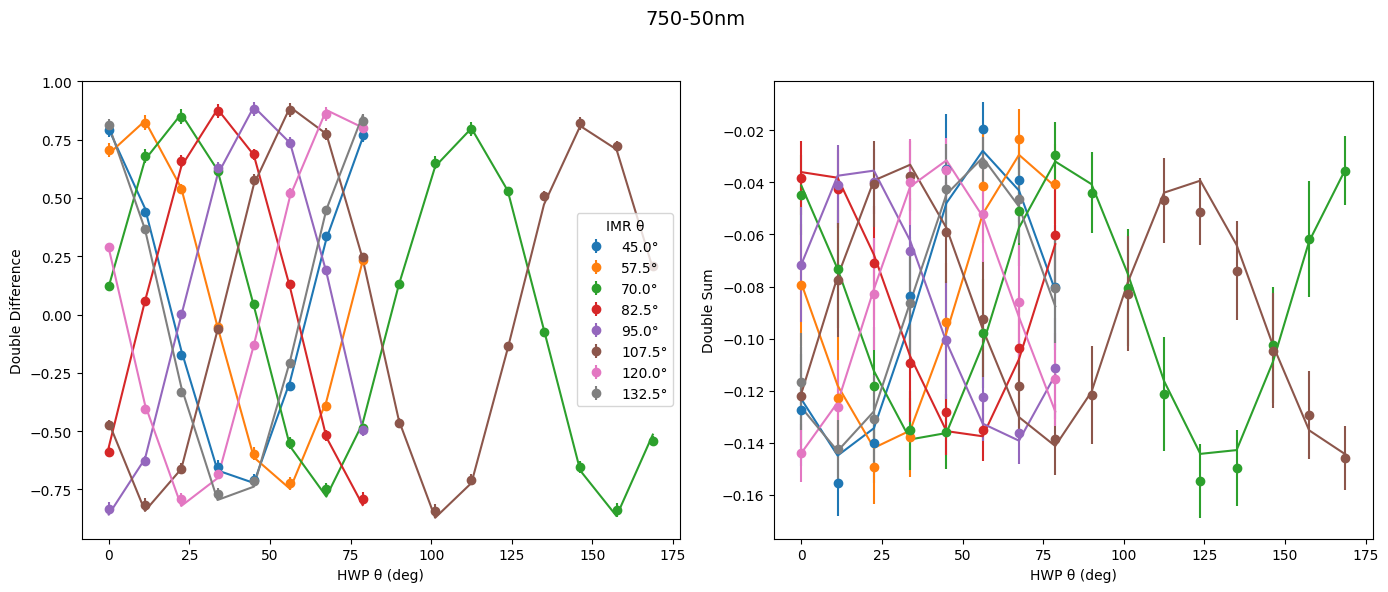

After p0: {'dichroic': {'phi': 2.6466996947527264, 'epsilon': 0.0026598124844908746, 'theta': 5.314556055732357}, 'flc': {'phi': 3.089941266840107, 'delta_theta': 4.999366728827939}, 'optics': {'phi': 0.9924126811759615, 'epsilon': 0.0695382870665548, 'theta': -71.96874405478971}, 'image_rotator': {'phi': 3.0774432970903582}, 'hwp': {'phi': 3.048693565052087, 'delta_theta': 2.537391092608269}, 'lp': {'theta': 4.999998745076439}}
Before p0: {'dichroic': {'phi': 2.6466996947527264, 'epsilon': 0.0026598124844908746, 'theta': 5.314556055732357}, 'flc': {'phi': 3.089941266840107, 'delta_theta': 4.999366728827939}, 'optics': {'phi': 0.9924126811759615, 'epsilon': 0.0695382870665548, 'theta': -71.96874405478971}, 'image_rotator': {'phi': 3.0774432970903582}, 'hwp': {'phi': 3.048693565052087, 'delta_theta': 2.537391092608269}, 'lp': {'theta': 4.999998745076439}}
Iteration #: 25
logl_value: 24.71500625832228
Best Fit Parameters: [ 2.64715553e+00  2.66025013e-03  5.31780460e+00  3.08998063e+00
 

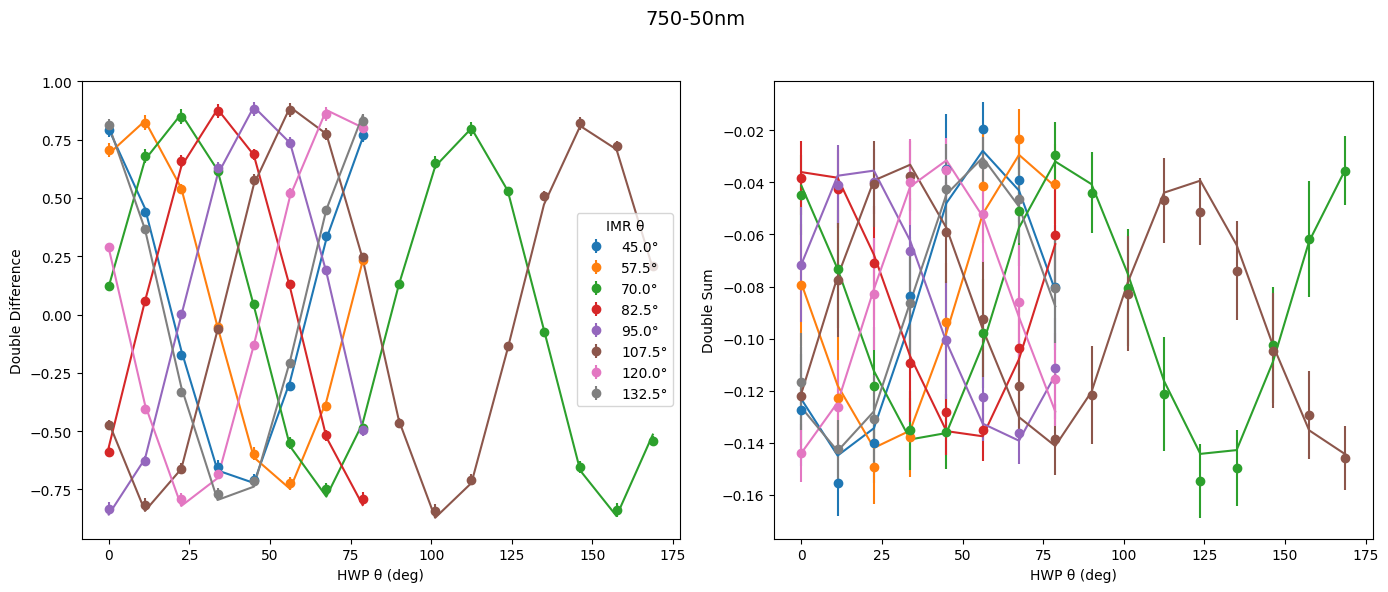

After p0: {'dichroic': {'phi': 2.6471555318540423, 'epsilon': 0.002660250132600913, 'theta': 5.317804602223612}, 'flc': {'phi': 3.089980628911621, 'delta_theta': 4.999995035694408}, 'optics': {'phi': 0.9924524213608831, 'epsilon': 0.06954001512001734, 'theta': -71.97457162370992}, 'image_rotator': {'phi': 3.0774372496968105}, 'hwp': {'phi': 3.0486960049305356, 'delta_theta': 2.5403647995243417}, 'lp': {'theta': 4.999960883076783}}
Before p0: {'dichroic': {'phi': 2.6471555318540423, 'epsilon': 0.002660250132600913, 'theta': 5.317804602223612}, 'flc': {'phi': 3.089980628911621, 'delta_theta': 4.999995035694408}, 'optics': {'phi': 0.9924524213608831, 'epsilon': 0.06954001512001734, 'theta': -71.97457162370992}, 'image_rotator': {'phi': 3.0774372496968105}, 'hwp': {'phi': 3.0486960049305356, 'delta_theta': 2.5403647995243417}, 'lp': {'theta': 4.999960883076783}}
Iteration #: 26
logl_value: 24.715001518736265
Best Fit Parameters: [ 2.64736865e+00  2.66036818e-03  5.31702532e+00  3.09009509e

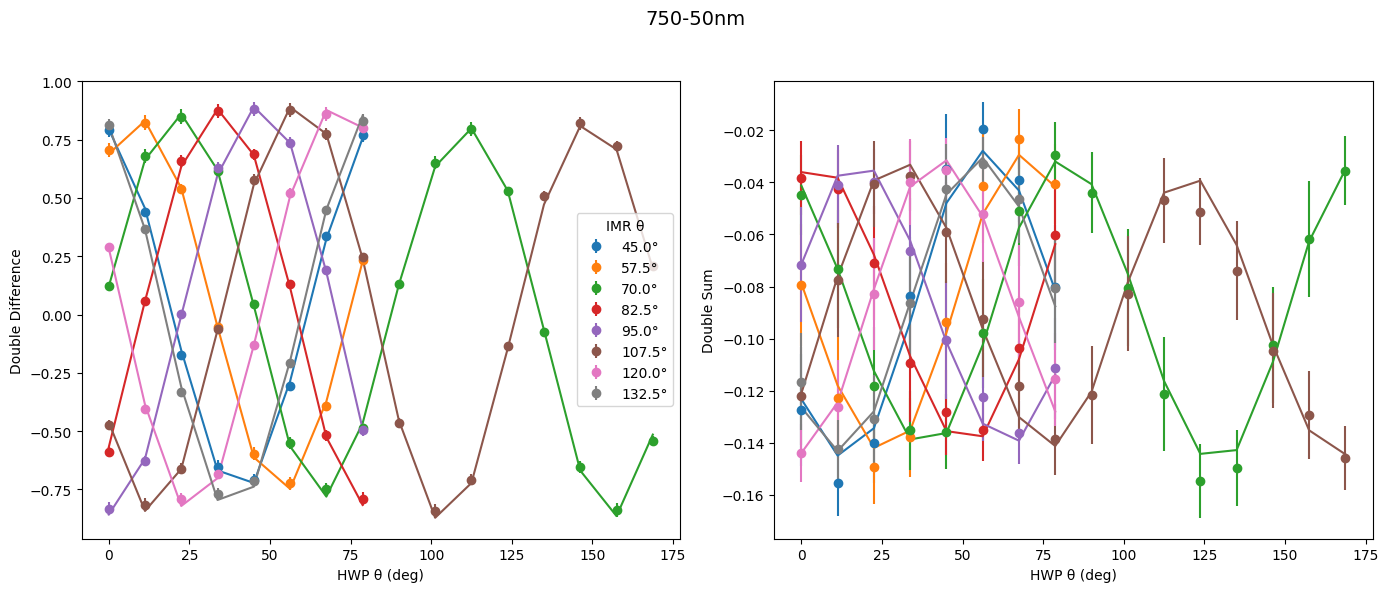

After p0: {'dichroic': {'phi': 2.6473686507856975, 'epsilon': 0.0026603681751891355, 'theta': 5.317025321750805}, 'flc': {'phi': 3.0900950902907063, 'delta_theta': 4.999999987143285}, 'optics': {'phi': 0.9925809178347433, 'epsilon': 0.06953811934441695, 'theta': -71.97398390210859}, 'image_rotator': {'phi': 3.0774358258448213}, 'hwp': {'phi': 3.0486955596291256, 'delta_theta': 2.539892548583383}, 'lp': {'theta': 5.0}}
Before p0: {'dichroic': {'phi': 2.6473686507856975, 'epsilon': 0.0026603681751891355, 'theta': 5.317025321750805}, 'flc': {'phi': 3.0900950902907063, 'delta_theta': 4.999999987143285}, 'optics': {'phi': 0.9925809178347433, 'epsilon': 0.06953811934441695, 'theta': -71.97398390210859}, 'image_rotator': {'phi': 3.0774358258448213}, 'hwp': {'phi': 3.0486955596291256, 'delta_theta': 2.539892548583383}, 'lp': {'theta': 5.0}}
Iteration #: 27
logl_value: 24.715001447799988
Best Fit Parameters: [ 2.64731840e+00  2.66030941e-03  5.31709478e+00  3.09007233e+00
  5.00000000e+00  9.92

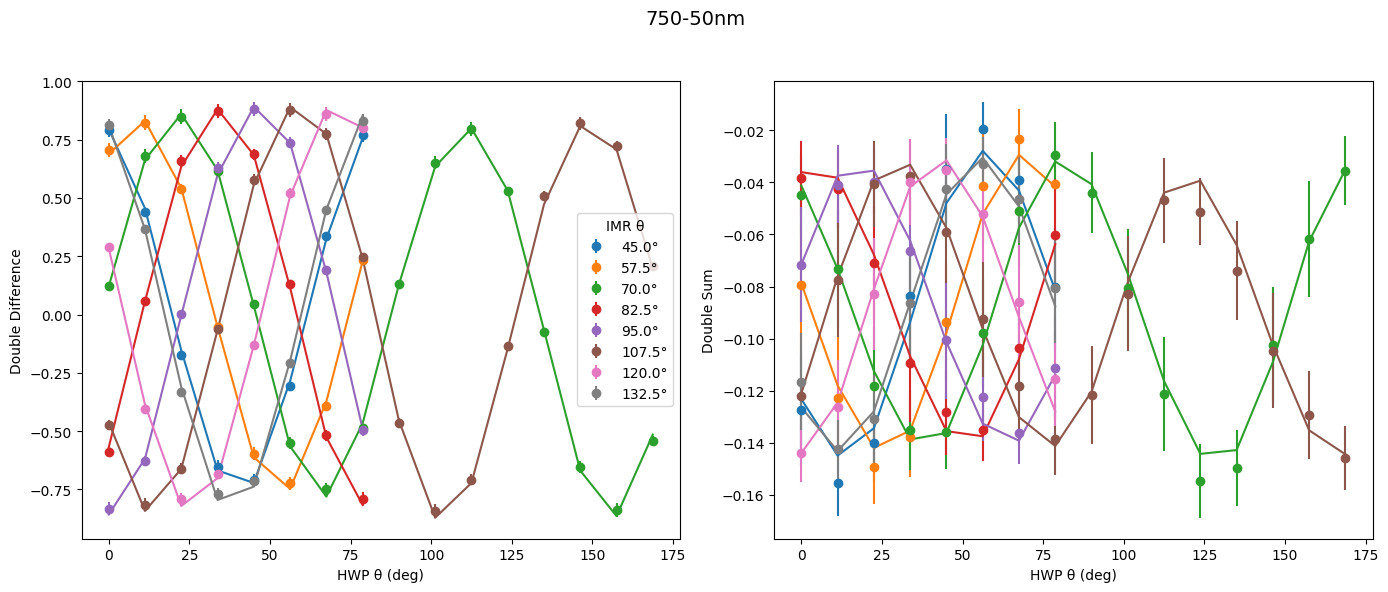

After p0: {'dichroic': {'phi': 2.6473184006903665, 'epsilon': 0.0026603094106601947, 'theta': 5.317094779476092}, 'flc': {'phi': 3.0900723306562137, 'delta_theta': 5.0}, 'optics': {'phi': 0.9925571259917226, 'epsilon': 0.06953888069652725, 'theta': -71.97391575740765}, 'image_rotator': {'phi': 3.077437600347208}, 'hwp': {'phi': 3.048696895851962, 'delta_theta': 2.539872866566271}, 'lp': {'theta': 4.999999952010871}}
Before p0: {'dichroic': {'phi': 2.6473184006903665, 'epsilon': 0.0026603094106601947, 'theta': 5.317094779476092}, 'flc': {'phi': 3.0900723306562137, 'delta_theta': 5.0}, 'optics': {'phi': 0.9925571259917226, 'epsilon': 0.06953888069652725, 'theta': -71.97391575740765}, 'image_rotator': {'phi': 3.077437600347208}, 'hwp': {'phi': 3.048696895851962, 'delta_theta': 2.539872866566271}, 'lp': {'theta': 4.999999952010871}}
Iteration #: 28
logl_value: 24.715001351601614
Best Fit Parameters: [ 2.64733393e+00  2.66032094e-03  5.31692089e+00  3.09008923e+00
  5.00000000e+00  9.925542

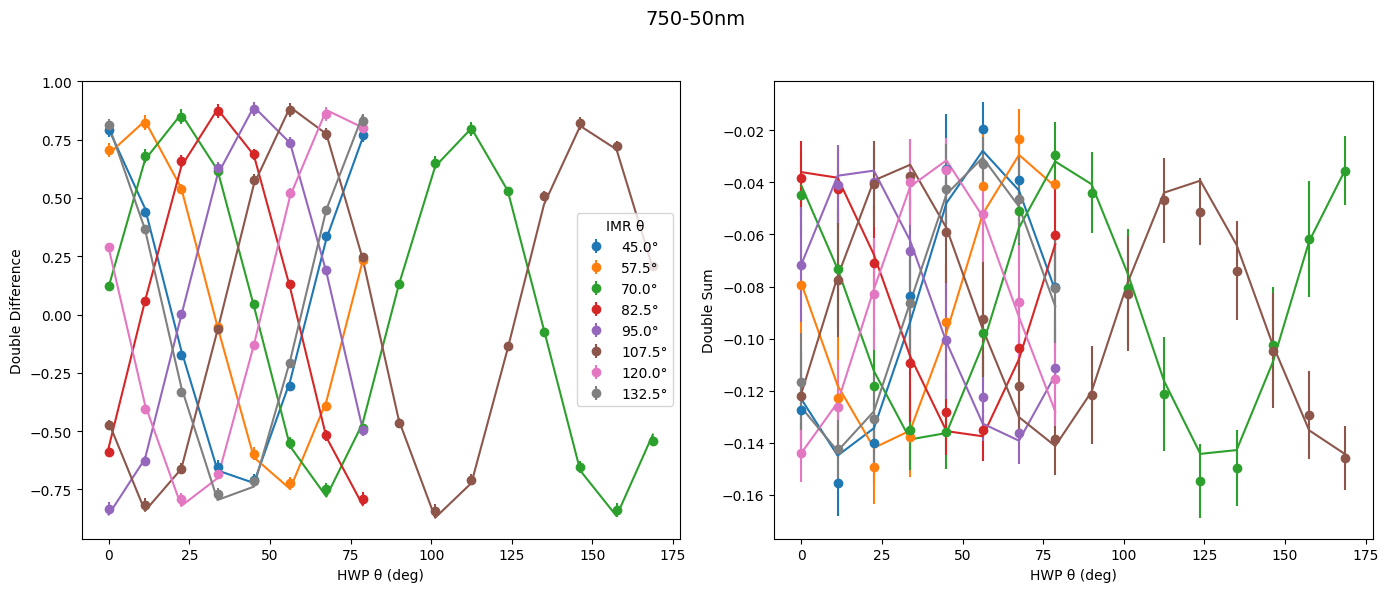

After p0: {'dichroic': {'phi': 2.647333927997738, 'epsilon': 0.002660320937930379, 'theta': 5.3169208945647775}, 'flc': {'phi': 3.0900892252080636, 'delta_theta': 4.999999998679553}, 'optics': {'phi': 0.9925542354554062, 'epsilon': 0.06953879797370438, 'theta': -71.97344690923958}, 'image_rotator': {'phi': 3.077437753537164}, 'hwp': {'phi': 3.048696095423396, 'delta_theta': 2.5398701861612665}, 'lp': {'theta': 4.999999976128674}}
Before p0: {'dichroic': {'phi': 2.647333927997738, 'epsilon': 0.002660320937930379, 'theta': 5.3169208945647775}, 'flc': {'phi': 3.0900892252080636, 'delta_theta': 4.999999998679553}, 'optics': {'phi': 0.9925542354554062, 'epsilon': 0.06953879797370438, 'theta': -71.97344690923958}, 'image_rotator': {'phi': 3.077437753537164}, 'hwp': {'phi': 3.048696095423396, 'delta_theta': 2.5398701861612665}, 'lp': {'theta': 4.999999976128674}}
Iteration #: 29
logl_value: 24.715001297794338
Best Fit Parameters: [ 2.64731343e+00  2.66028463e-03  5.31685129e+00  3.09008412e+0

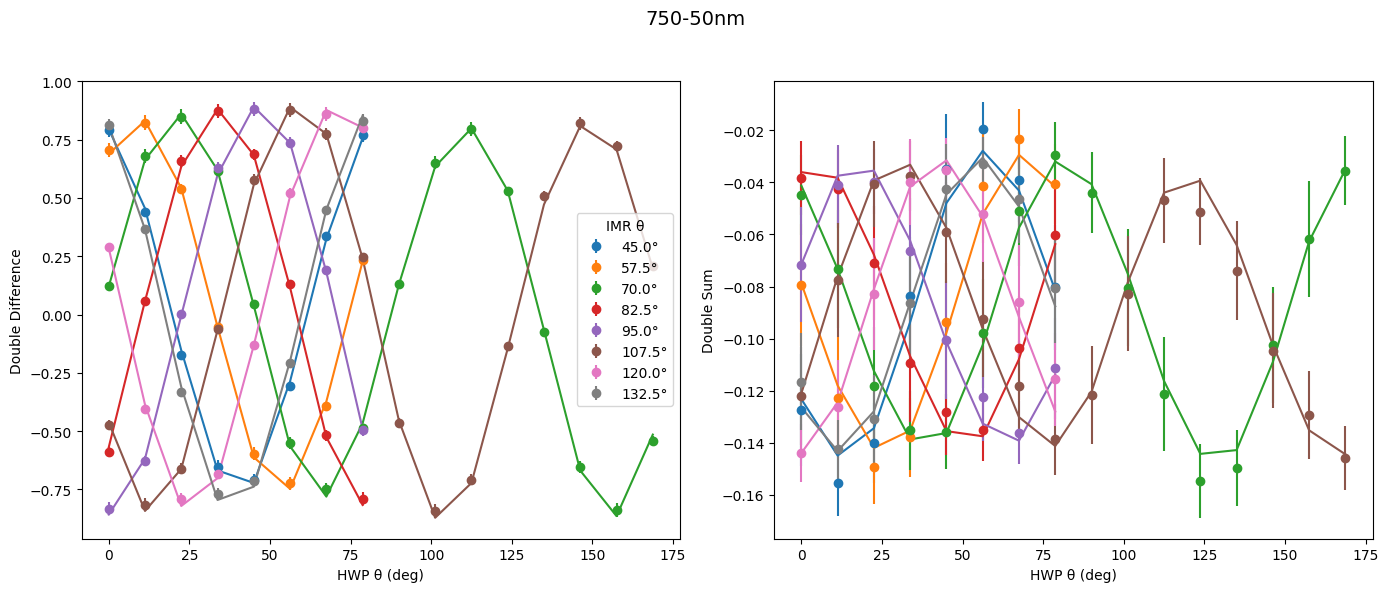

After p0: {'dichroic': {'phi': 2.6473134259812663, 'epsilon': 0.0026602846295122077, 'theta': 5.316851289871266}, 'flc': {'phi': 3.090084121405713, 'delta_theta': 4.999999987098153}, 'optics': {'phi': 0.9925464897549205, 'epsilon': 0.06953899038038452, 'theta': -71.97325402941274}, 'image_rotator': {'phi': 3.077437525673675}, 'hwp': {'phi': 3.0486960052610064, 'delta_theta': 2.539794298826412}, 'lp': {'theta': 4.999999996432798}}
Before p0: {'dichroic': {'phi': 2.6473134259812663, 'epsilon': 0.0026602846295122077, 'theta': 5.316851289871266}, 'flc': {'phi': 3.090084121405713, 'delta_theta': 4.999999987098153}, 'optics': {'phi': 0.9925464897549205, 'epsilon': 0.06953899038038452, 'theta': -71.97325402941274}, 'image_rotator': {'phi': 3.077437525673675}, 'hwp': {'phi': 3.0486960052610064, 'delta_theta': 2.539794298826412}, 'lp': {'theta': 4.999999996432798}}
Iteration #: 30
logl_value: 24.715001297794338
Best Fit Parameters: [ 2.64731343e+00  2.66028463e-03  5.31685129e+00  3.09008412e+0

In [14]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds = [ 
    (-2 * np.pi, 2 * np.pi), # dichroic_retardance
    (0, 1), # dichroic_diattenuation
    (-90, 90), # dichroic_rotation_angle 
    (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # delta_FLC
    (-5, 5),  # rot_FLC
    (-np.pi, np.pi),  # delta_opts
    (0, 0.1),  # epsilon_opts
    (-90, 90),  # rot_opts
    ((delta_derot - delta_derot * 0.1), (delta_derot + delta_derot * 0.1)),  # delta_derot
    ((delta_HWP - delta_HWP * 0.1), (delta_HWP + delta_HWP * 0.1)),  # delta_HWP
    (-5, 5),  # offset_HWP
    (-5, 5),  # theta_pol
]
# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_fixed_EM_gain_iterate_on_any_improvement_with_dichroic_best_fit.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

    iteration += 1

# Step 6: Plot model with best fit

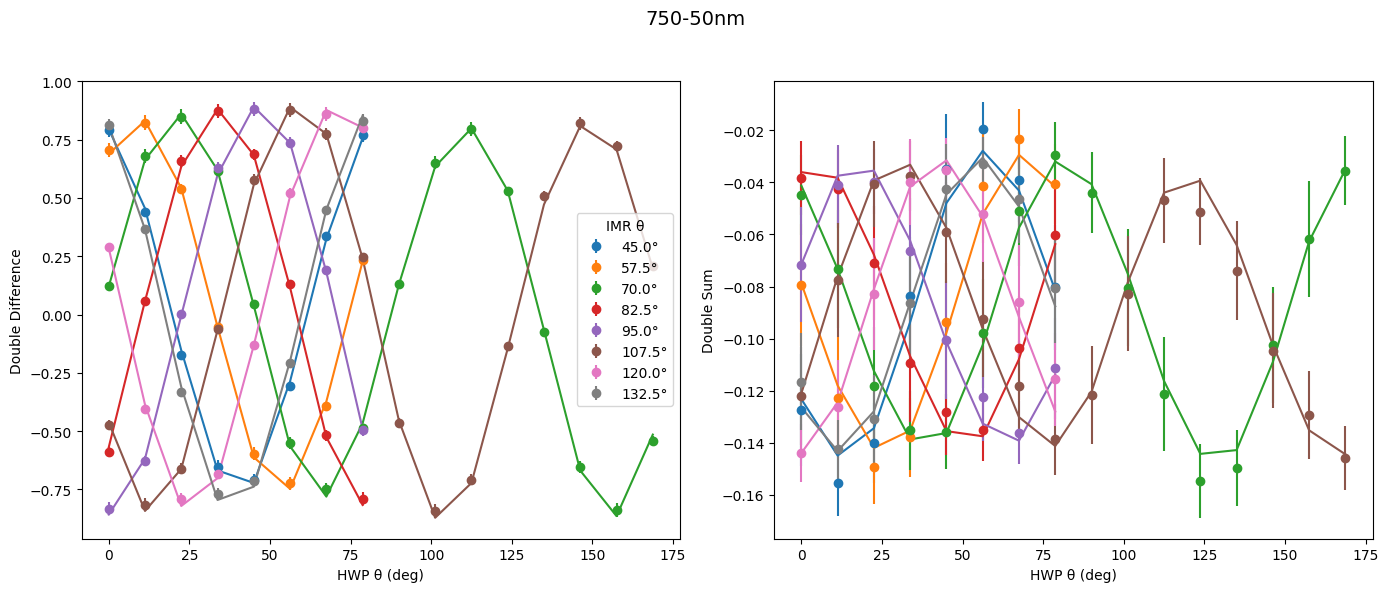

In [15]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)